# Three-Variable Panel VAR: Utilization × Volatility × Liquidations

**Panel:** 12 CSUs (5 Base + 7 Ethereum), 364 daily observations (Jan 3 – Dec 31, 2024)  
**Variables:** Utilization (leverage proxy), Collateral basket volatility (14-day rolling), Liquidations (log collateral USD seized)  
**Method:** Fixed-effects VAR with Cholesky identification, bootstrap confidence intervals  
**Ordering:** Utilization → Volatility → Liquidations (slow to fast)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## 1. Load Gold Panel

In [2]:
df = pd.read_parquet('../data/gold/panel_base_eth/gold_panel_base_eth.parquet')
df['date'] = df['date'].astype(str)

print(f"Raw panel: {len(df):,} obs, {df['csu'].nunique()} CSUs")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Columns: {list(df.columns)}")
print(f"\nCoverage:")
for col in ['utilization', 'volatility', 'n_liquidations', 'total_collateral_usd']:
    cov = df[col].notna().mean() * 100
    print(f"  {col}: {cov:.1f}%")

Raw panel: 4,368 obs, 12 CSUs
Date range: 2024-01-03 to 2024-12-31
Columns: ['date', 'csu', 'n_liquidations', 'total_collateral_usd', 'total_debt_usd', 'n_unique_borrowers', 'n_unique_liquidators', 'has_liquidation', 'log_collateral_usd', 'log_debt_usd', 'log_n_liquidations', 'utilization', 'total_supply_usd', 'total_borrow_usd', 'basket_return', 'volatility']

Coverage:
  utilization: 75.2%
  volatility: 75.0%
  n_liquidations: 100.0%
  total_collateral_usd: 100.0%


## 2. Prepare Analysis Variables

We use three variables:
1. **Utilization** — borrowed USD / supplied USD (bounded [0,1])
2. **Volatility** — 14-day rolling std of collateral basket log returns
3. **Liquidation** — log(1 + total_collateral_usd) to handle zero-liquidation days

Drop rows where utilization or volatility is missing (markets not yet deployed).

In [3]:
# Create liquidation variable (log transform to handle zeros and skewness)
df['liquidation'] = np.log1p(df['total_collateral_usd'])

# Drop rows missing utilization or volatility (market not yet deployed)
df_clean = df.dropna(subset=['utilization', 'volatility']).copy()

print(f"After dropping missing util/vol: {len(df_clean):,} obs, {df_clean['csu'].nunique()} CSUs")
print(f"Date range: {df_clean['date'].min()} to {df_clean['date'].max()}")
print(f"\nAll CSUs:")
for csu in sorted(df_clean['csu'].unique()):
    sub = df_clean[df_clean['csu'] == csu]
    chain = 'base' if '_base' in csu or 'moonwell' in csu else 'ethereum'
    print(f"  {csu} ({chain}): {len(sub)} obs, util={sub['utilization'].mean():.3f}, "
          f"vol={sub['volatility'].mean():.4f}, liq_days={sub['has_liquidation'].sum()}")

After dropping missing util/vol: 3,274 obs, 12 CSUs
Date range: 2024-01-03 to 2024-12-31

All CSUs:
  aave_v3_base (base): 364 obs, util=0.456, vol=0.0217, liq_days=277
  aave_v3_ethereum (ethereum): 364 obs, util=0.390, vol=0.0202, liq_days=295
  compound_v3_base_aero (base): 81 obs, util=0.205, vol=0.0344, liq_days=2
  compound_v3_base_usdc (base): 286 obs, util=0.309, vol=0.0184, liq_days=36
  compound_v3_base_weth (base): 364 obs, util=0.349, vol=0.0291, liq_days=6
  compound_v3_eth_usdc (ethereum): 364 obs, util=0.284, vol=0.0163, liq_days=60
  compound_v3_eth_usds (ethereum): 73 obs, util=0.336, vol=0.0151, liq_days=1
  compound_v3_eth_usdt (ethereum): 178 obs, util=0.261, vol=0.0156, liq_days=11
  compound_v3_eth_weth (ethereum): 364 obs, util=0.390, vol=0.0289, liq_days=1
  compound_v3_eth_wsteth (ethereum): 108 obs, util=0.193, vol=0.0301, liq_days=0
  moonwell_lending_base (base): 364 obs, util=0.598, vol=0.0220, liq_days=0
  sparklend_ethereum (ethereum): 364 obs, util=0.354

## 3. Define Subsamples

In [4]:
base_csus = [
    'aave_v3_base', 'compound_v3_base_aero', 'compound_v3_base_usdc',
    'compound_v3_base_weth', 'moonwell_lending_base',
]

eth_csus = [
    'aave_v3_ethereum', 'compound_v3_eth_usdc', 'compound_v3_eth_usds',
    'compound_v3_eth_usdt', 'compound_v3_eth_weth',
    'compound_v3_eth_wsteth', 'sparklend_ethereum',
]

# Pooled architecture = Aave, Moonwell, SparkLend (shared collateral pool)
pooled_csus = ['aave_v3_base', 'aave_v3_ethereum', 'moonwell_lending_base', 'sparklend_ethereum']

# Isolated architecture = Compound V3 (single base asset per market)
isolated_csus = [c for c in base_csus + eth_csus if 'compound' in c]

# Filter to CSUs present in clean data
valid = set(df_clean['csu'].unique())
base_csus = [c for c in base_csus if c in valid]
eth_csus = [c for c in eth_csus if c in valid]
pooled_csus = [c for c in pooled_csus if c in valid]
isolated_csus = [c for c in isolated_csus if c in valid]

samples = {
    'Full Sample': base_csus + eth_csus,
    'Base Chain': base_csus,
    'Ethereum': eth_csus,
    'Pooled': pooled_csus,
    'Isolated': isolated_csus,
}

for label, csus in samples.items():
    sub = df_clean[df_clean['csu'].isin(csus)]
    print(f"{label:15s}: {len(csus):2d} CSUs, {len(sub):,} obs, "
          f"liq events={sub['n_liquidations'].sum():,}")

Full Sample    : 12 CSUs, 3,274 obs, liq events=13,022
Base Chain     :  5 CSUs, 1,459 obs, liq events=6,680
Ethereum       :  7 CSUs, 1,815 obs, liq events=6,342
Pooled         :  4 CSUs, 1,456 obs, liq events=11,272
Isolated       :  8 CSUs, 1,818 obs, liq events=1,750


## 4. Summary Statistics

In [5]:
rows = []
for label, csus in samples.items():
    sub = df_clean[df_clean['csu'].isin(csus)]
    rows.append({
        'Sample': label,
        'N (CSUs)': sub['csu'].nunique(),
        'T (dates)': sub['date'].nunique(),
        'Obs': len(sub),
        'Util Mean': sub['utilization'].mean(),
        'Util SD': sub['utilization'].std(),
        'Vol Mean': sub['volatility'].mean(),
        'Vol SD': sub['volatility'].std(),
        'Liq/Day Mean': sub['n_liquidations'].mean(),
        'Liq/Day SD': sub['n_liquidations'].std(),
        '% Days w/ Liq': 100 * sub['has_liquidation'].mean(),
        'Avg Coll USD': sub.loc[sub['n_liquidations'] > 0, 'total_collateral_usd'].mean(),
    })

summary_df = pd.DataFrame(rows)
print("Table 1: Panel Summary Statistics")
print("=" * 110)
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}" if abs(x) < 1 else f"{x:,.1f}"))

Table 1: Panel Summary Statistics
     Sample  N (CSUs)  T (dates)  Obs  Util Mean  Util SD  Vol Mean  Vol SD  Liq/Day Mean  Liq/Day SD  % Days w/ Liq  Avg Coll USD
Full Sample        12        364 3274     0.3737   0.1110    0.0224  0.0108           4.0        41.6           23.7     954,958.7
 Base Chain         5        364 1459     0.4218   0.1312    0.0237  0.0113           4.6        43.3           22.0      28,993.6
   Ethereum         7        364 1815     0.3350   0.0710    0.0214  0.0102           3.5        40.2           25.1   1,606,789.5
     Pooled         4        364 1456     0.4493   0.0985    0.0214  0.0093           7.7        59.3           45.3     921,977.5
   Isolated         8        364 1818     0.3131   0.0786    0.0232  0.0117        0.9626        16.8            6.4   1,141,006.5


## 5. Panel VAR Estimation Function

**Procedure:**
1. Within-transform (demean by CSU) to remove fixed effects
2. Estimate VAR(p) on the demeaned panel
3. Select lag order via BIC (capped at 5)
4. Orthogonalized IRF via Cholesky: utilization → volatility → liquidation
5. 95% bootstrap CIs (500 replications, residual resampling)
6. Granger causality F-tests in all 6 pairwise directions

In [6]:
VAR_COLS = ['utilization', 'volatility', 'liquidation']
FE_COLS = ['util_fe', 'vol_fe', 'liq_fe']
VAR_LABELS = {'util_fe': 'Utilization', 'vol_fe': 'Volatility', 'liq_fe': 'Liquidation'}
IDX_MAP = {0: 'util', 1: 'vol', 2: 'liq'}  # Cholesky order

def run_panel_var_3v(df, csus, label, max_lags=10, irf_periods=20, n_boot=500):
    """
    Run 3-variable fixed-effects Panel VAR.
    Returns dict with results, IRFs, bootstrap CIs, Granger tests.
    """
    sub = df[df['csu'].isin(csus)].copy()
    sub = sub.dropna(subset=VAR_COLS)
    
    # Fixed effects: within-transformation (demean by CSU)
    for orig, fe in zip(VAR_COLS, FE_COLS):
        sub[fe] = sub.groupby('csu')[orig].transform(lambda x: x - x.mean())
    
    panel = sub[FE_COLS].dropna()
    print(f"  Panel: {len(panel):,} obs after FE transform")
    
    # Fit VAR with BIC-selected lags
    model = VAR(panel)
    try:
        lo = model.select_order(maxlags=min(max_lags, len(panel) // 10))
        optimal = max(1, min(lo.bic, 5))
        print(f"  Lag selection — AIC: {lo.aic}, BIC: {lo.bic}, HQIC: {lo.hqic} → using {optimal}")
    except:
        optimal = 2
        print(f"  Lag selection failed, using {optimal}")
    
    results = model.fit(optimal)
    
    # Orthogonalized IRFs
    irf = results.irf(irf_periods)
    irf_orth = irf.orth_irfs  # shape: (periods+1, 3, 3)
    
    # Bootstrap CIs (residual resampling)
    rng = np.random.RandomState(42)
    boot_irfs = []
    resids = results.resid.values
    fitted = results.fittedvalues.values
    
    for _ in range(n_boot):
        idx = rng.choice(len(resids), size=len(resids), replace=True)
        boot_data = fitted + resids[idx]
        try:
            br = VAR(pd.DataFrame(boot_data, columns=panel.columns)).fit(optimal)
            boot_irfs.append(br.irf(irf_periods).orth_irfs)
        except:
            continue
    
    ci_lo = ci_hi = None
    if len(boot_irfs) > 50:
        ba = np.array(boot_irfs)
        ci_lo = np.percentile(ba, 2.5, axis=0)
        ci_hi = np.percentile(ba, 97.5, axis=0)
        print(f"  Bootstrap: {len(boot_irfs)}/{n_boot} successful replications")
    
    # Granger causality — all 6 pairwise directions
    gc = {}
    pairs = [
        ('util_fe', 'vol_fe',  'Util→Vol'),
        ('vol_fe',  'util_fe', 'Vol→Util'),
        ('util_fe', 'liq_fe',  'Util→Liq'),
        ('liq_fe',  'util_fe', 'Liq→Util'),
        ('vol_fe',  'liq_fe',  'Vol→Liq'),
        ('liq_fe',  'vol_fe',  'Liq→Vol'),
    ]
    for cause, effect, name in pairs:
        try:
            test = results.test_causality(effect, [cause], kind='f')
            gc[name] = {'F': test.test_statistic, 'p': test.pvalue}
        except:
            pass
    
    return {
        'label': label,
        'results': results,
        'irf_orth': irf_orth,
        'ci_lo': ci_lo,
        'ci_hi': ci_hi,
        'gc': gc,
        'n_csus': sub['csu'].nunique(),
        'n_obs': len(sub),
        'lags': optimal,
    }

## 6. Run All Analyses

In [7]:
all_results = {}
for label, csus in samples.items():
    print(f"\n{'='*60}")
    print(f"  {label} ({len(csus)} CSUs)")
    print(f"{'='*60}")
    all_results[label] = run_panel_var_3v(df_clean, csus, label)


  Full Sample (12 CSUs)
  Panel: 3,274 obs after FE transform
  Lag selection — AIC: 10, BIC: 2, HQIC: 2 → using 2


  Bootstrap: 500/500 successful replications

  Base Chain (5 CSUs)
  Panel: 1,459 obs after FE transform
  Lag selection — AIC: 10, BIC: 2, HQIC: 3 → using 2


  Bootstrap: 500/500 successful replications

  Ethereum (7 CSUs)
  Panel: 1,815 obs after FE transform
  Lag selection — AIC: 10, BIC: 1, HQIC: 1 → using 1


  Bootstrap: 500/500 successful replications

  Pooled (4 CSUs)
  Panel: 1,456 obs after FE transform
  Lag selection — AIC: 10, BIC: 2, HQIC: 2 → using 2


  Bootstrap: 500/500 successful replications

  Isolated (8 CSUs)
  Panel: 1,818 obs after FE transform
  Lag selection — AIC: 9, BIC: 2, HQIC: 2 → using 2


  Bootstrap: 500/500 successful replications


## 7. Granger Causality Tests — All 6 Pairwise Directions

In [8]:
def stars(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

gc_directions = ['Util→Vol', 'Vol→Util', 'Util→Liq', 'Liq→Util', 'Vol→Liq', 'Liq→Vol']

gc_rows = []
for label, res in all_results.items():
    row = {'Sample': label, 'N': res['n_csus'], 'Lags': res['lags']}
    for d in gc_directions:
        if d in res['gc']:
            f_val = res['gc'][d]['F']
            p_val = res['gc'][d]['p']
            row[f'F({d})'] = f'{f_val:.3f}'
            row[f'p({d})'] = f'{p_val:.4f}{stars(p_val)}'
        else:
            row[f'F({d})'] = '—'
            row[f'p({d})'] = '—'
    gc_rows.append(row)

gc_df = pd.DataFrame(gc_rows)
print("Table 2: Granger Causality Tests (All Pairwise Directions)")
print("=" * 130)
print(gc_df.to_string(index=False))
print("\n*** p<0.01, ** p<0.05, * p<0.10")

Table 2: Granger Causality Tests (All Pairwise Directions)
     Sample  N  Lags F(Util→Vol) p(Util→Vol) F(Vol→Util) p(Vol→Util) F(Util→Liq) p(Util→Liq) F(Liq→Util) p(Liq→Util) F(Vol→Liq) p(Vol→Liq) F(Liq→Vol) p(Liq→Vol)
Full Sample 12     2       1.711      0.1807       0.735      0.4794       0.232      0.7933       1.846      0.1579      3.698   0.0248**     26.179  0.0000***
 Base Chain  5     2       0.373      0.6890       0.235      0.7902       0.525      0.5918       0.183      0.8326      1.805     0.1645      8.773  0.0002***
   Ethereum  7     1       0.004      0.9524       0.821      0.3649       0.070      0.7917       3.230     0.0724*      5.390   0.0203**     44.598  0.0000***
     Pooled  4     2       0.814      0.4431       0.200      0.8186       1.161      0.3132       5.708   0.0033***      4.736  0.0088***     24.633  0.0000***
   Isolated  8     2       0.881      0.4142       0.843      0.4305       0.376      0.6864       0.656      0.5188      0.655     0.51

## 8. IRF Plots — Full 3×3 Grid (Full Sample)

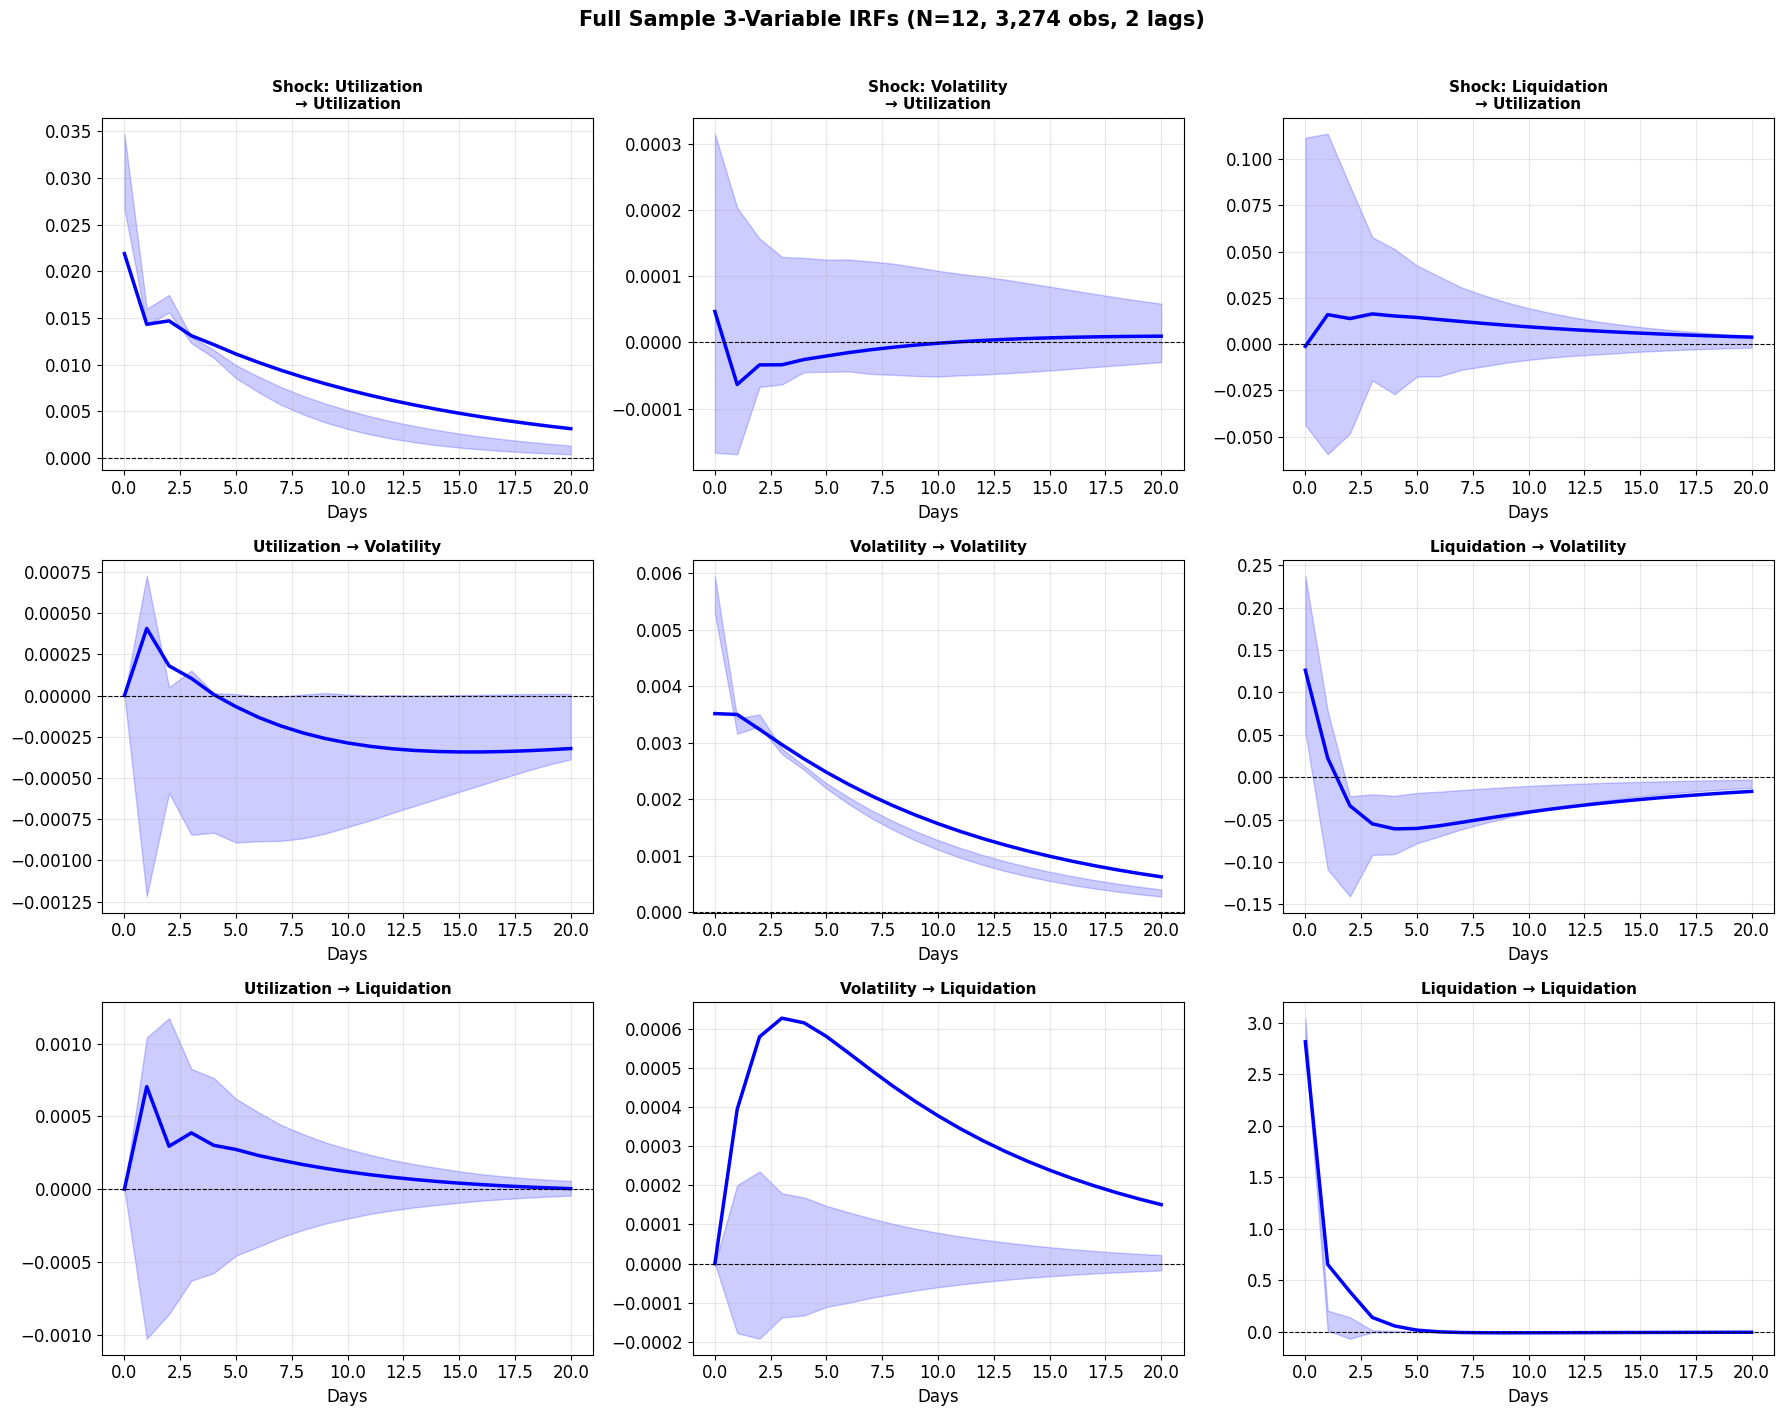

In [9]:
def plot_irf(res, imp_idx, resp_idx, title, ax, color='blue'):
    """Plot a single IRF path with bootstrap CI."""
    vals = res['irf_orth'][:, imp_idx, resp_idx]
    periods = range(len(vals))
    ax.plot(periods, vals, color=color, lw=2.5)
    if res['ci_lo'] is not None:
        ax.fill_between(periods,
                        res['ci_lo'][:, imp_idx, resp_idx],
                        res['ci_hi'][:, imp_idx, resp_idx],
                        alpha=0.2, color=color)
    ax.axhline(0, color='black', ls='--', lw=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Days')
    return ax

var_names = ['Utilization', 'Volatility', 'Liquidation']
res = all_results['Full Sample']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for i in range(3):  # impulse
    for j in range(3):  # response
        title = f'{var_names[i]} → {var_names[j]}'
        plot_irf(res, i, j, title, axes[j, i])
        if j == 0:
            axes[j, i].set_title(f'Shock: {var_names[i]}\n→ {var_names[j]}',
                                  fontsize=11, fontweight='bold')

fig.suptitle(f'Full Sample 3-Variable IRFs (N={res["n_csus"]}, {res["n_obs"]:,} obs, {res["lags"]} lags)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/irf_3var_full_grid.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 9. Key IRFs: Cross-Variable Responses by Subsample

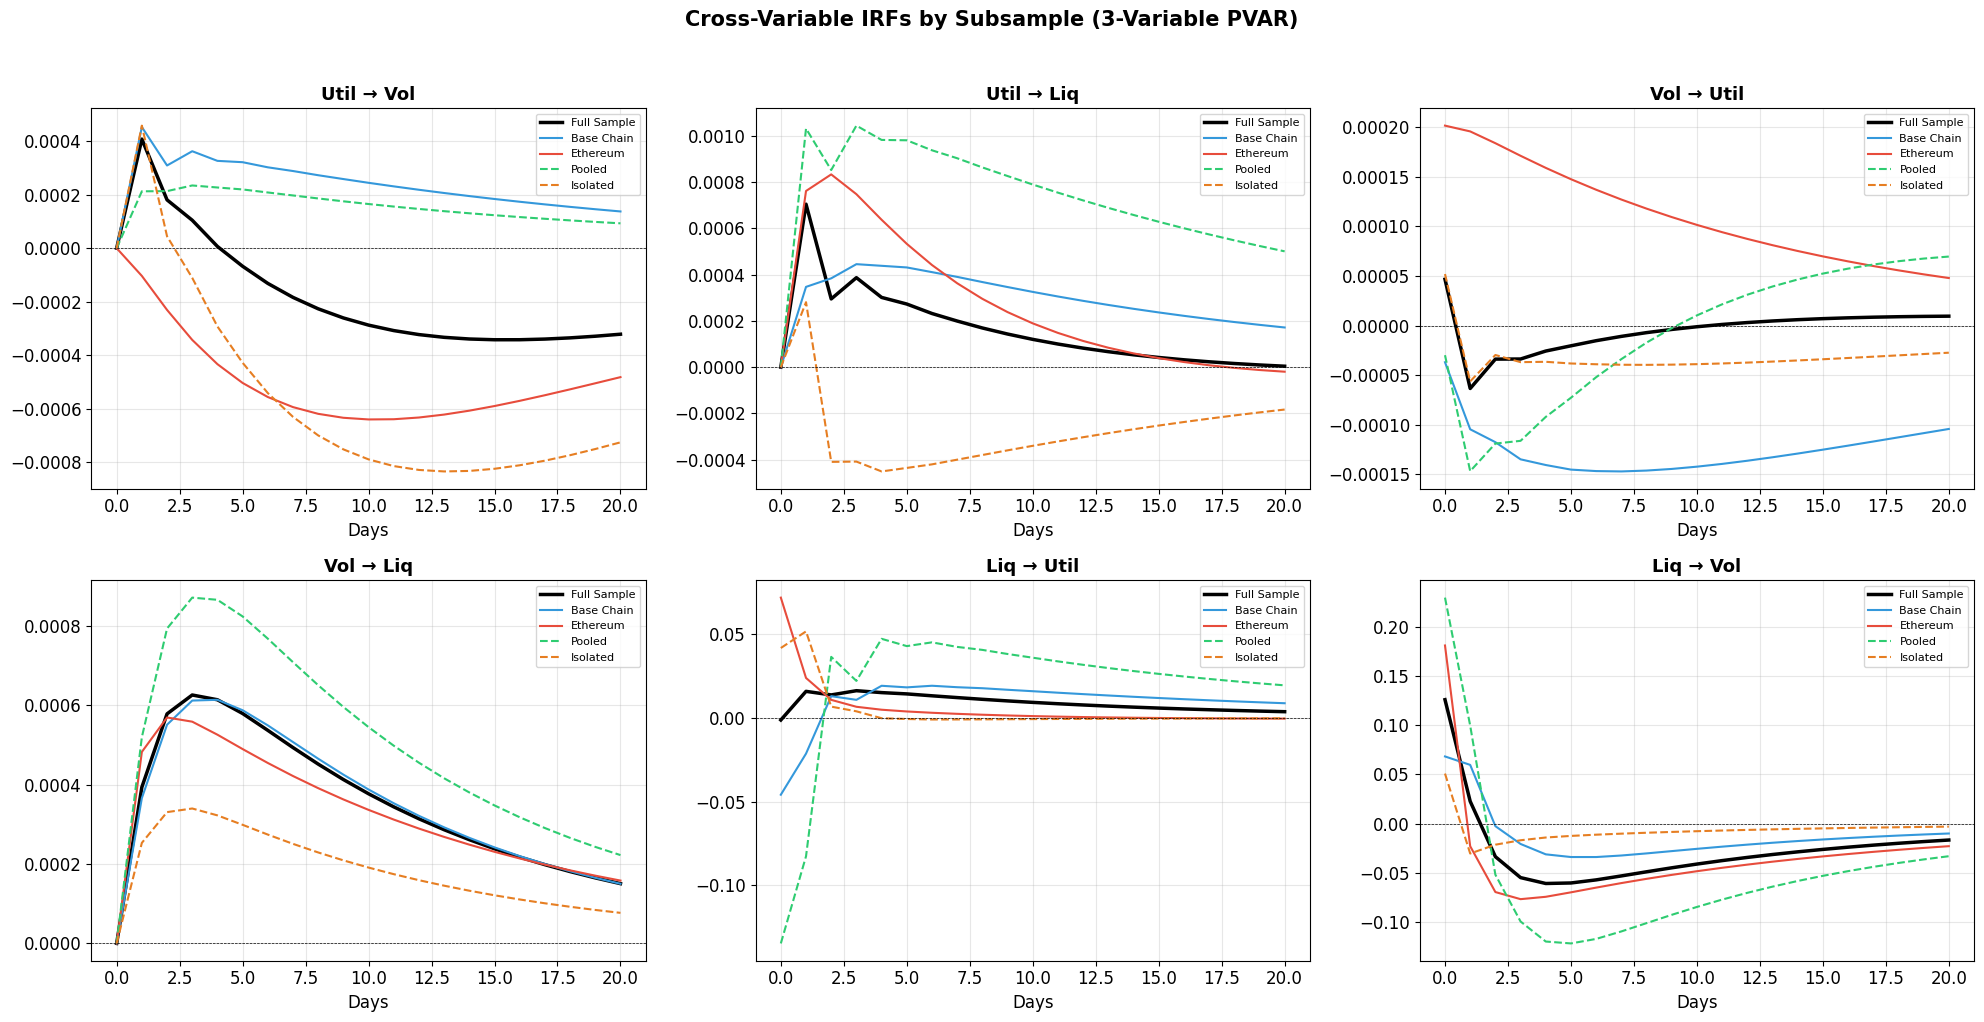

In [10]:
# The 6 cross-variable IRFs, compared across subsamples
cross_irfs = [
    (0, 1, 'Util → Vol'),
    (0, 2, 'Util → Liq'),
    (1, 0, 'Vol → Util'),
    (1, 2, 'Vol → Liq'),
    (2, 0, 'Liq → Util'),
    (2, 1, 'Liq → Vol'),
]

colors = {
    'Full Sample': 'black',
    'Base Chain': '#3498db',
    'Ethereum': '#e74c3c',
    'Pooled': '#2ecc71',
    'Isolated': '#e67e22',
}

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for ax, (imp, resp, title) in zip(axes.flat, cross_irfs):
    for label, res in all_results.items():
        vals = res['irf_orth'][:, imp, resp]
        lw = 2.5 if label == 'Full Sample' else 1.5
        ls = '-' if label in ('Full Sample', 'Base Chain', 'Ethereum') else '--'
        ax.plot(range(len(vals)), vals, color=colors[label], lw=lw, ls=ls, label=label)
    ax.axhline(0, color='black', ls='--', lw=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Days')
    ax.legend(fontsize=8)

fig.suptitle('Cross-Variable IRFs by Subsample (3-Variable PVAR)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/irf_3var_cross_comparison.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 10. Key Comparison: Base vs Ethereum — Volatility → Liquidation

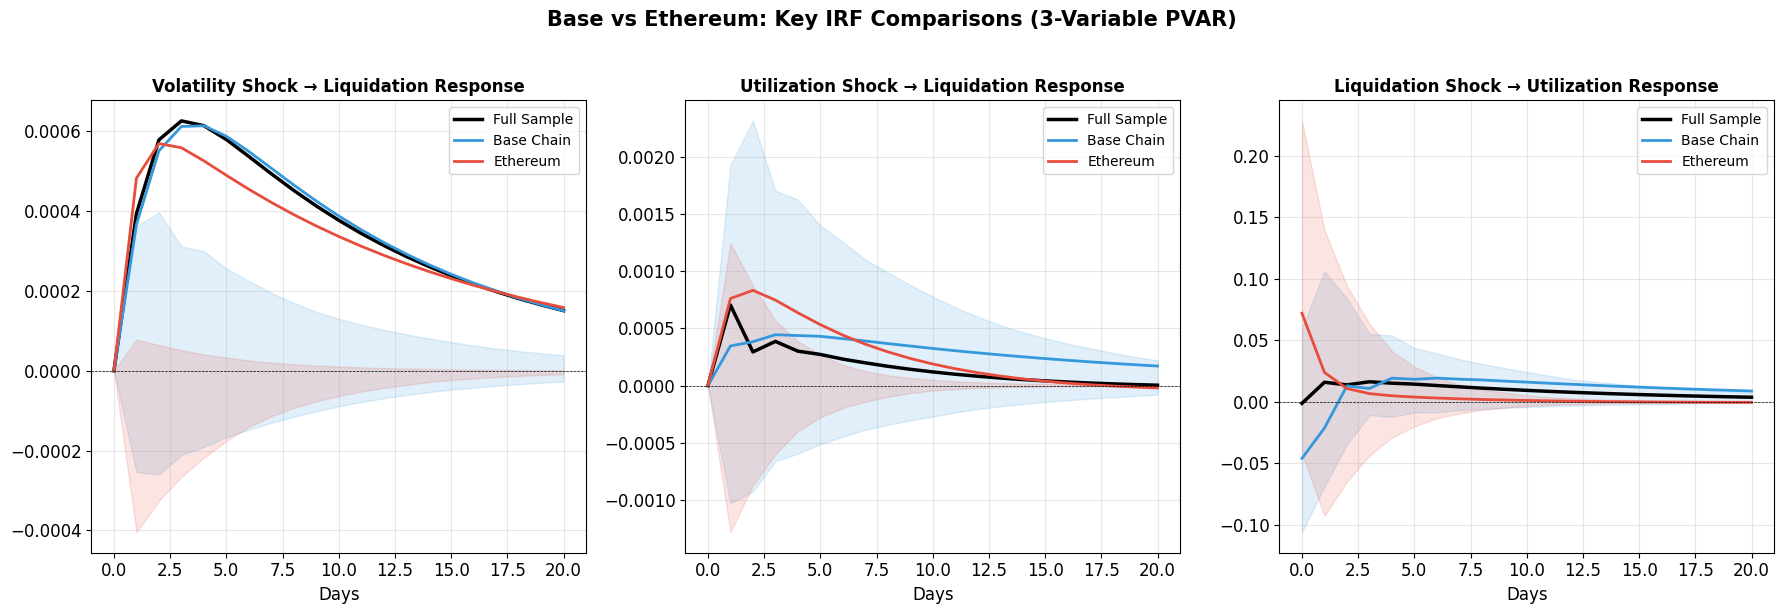

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

key_irfs = [
    (1, 2, 'Volatility Shock → Liquidation Response'),
    (0, 2, 'Utilization Shock → Liquidation Response'),
    (2, 0, 'Liquidation Shock → Utilization Response'),
]

chain_colors = {'Base Chain': '#3498db', 'Ethereum': '#e74c3c', 'Full Sample': 'black'}

for ax, (imp, resp, title) in zip(axes, key_irfs):
    for label in ['Full Sample', 'Base Chain', 'Ethereum']:
        res = all_results[label]
        vals = res['irf_orth'][:, imp, resp]
        periods = range(len(vals))
        lw = 2.5 if label == 'Full Sample' else 2.0
        ax.plot(periods, vals, color=chain_colors[label], lw=lw, label=label)
        if res['ci_lo'] is not None and label != 'Full Sample':
            ax.fill_between(periods,
                            res['ci_lo'][:, imp, resp],
                            res['ci_hi'][:, imp, resp],
                            alpha=0.15, color=chain_colors[label])
    ax.axhline(0, color='black', ls='--', lw=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Days')
    ax.legend(fontsize=10)

fig.suptitle('Base vs Ethereum: Key IRF Comparisons (3-Variable PVAR)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/irf_3var_base_vs_eth.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 11. IRF Summary Table

In [12]:
irf_rows = []
for label, res in all_results.items():
    for imp, resp, name in cross_irfs:
        vals = res['irf_orth'][:, imp, resp]
        peak_idx = int(np.argmax(np.abs(vals)))
        cumul = np.sum(vals)
        
        # Count significant horizons
        n_sig = 0
        if res['ci_lo'] is not None:
            for h in range(len(vals)):
                lo = res['ci_lo'][h, imp, resp]
                hi = res['ci_hi'][h, imp, resp]
                if lo > 0 or hi < 0:
                    n_sig += 1
        
        irf_rows.append({
            'Sample': label,
            'IRF Path': name,
            'Impact (t=1)': f'{vals[1]:.5f}',
            'Peak': f'{vals[peak_idx]:.5f}',
            'Peak Period': f't+{peak_idx}',
            'Cumulative': f'{cumul:.5f}',
            'Sign': '+' if cumul > 0 else '−',
            'Sig Horizons': f'{n_sig}/21',
        })

irf_df = pd.DataFrame(irf_rows)
print("Table 3: IRF Summary — All Cross-Variable Paths")
print("=" * 110)
# Print grouped by sample
for label in all_results:
    sub = irf_df[irf_df['Sample'] == label]
    print(f"\n--- {label} ---")
    print(sub.drop(columns='Sample').to_string(index=False))

Table 3: IRF Summary — All Cross-Variable Paths

--- Full Sample ---
  IRF Path Impact (t=1)     Peak Peak Period Cumulative Sign Sig Horizons
Util → Vol      0.00041  0.00041         t+1   -0.00377    −         2/21
Util → Liq      0.00070  0.00070         t+1    0.00326    +         0/21
Vol → Util     -0.00006 -0.00006         t+1   -0.00010    −         0/21
 Vol → Liq      0.00039  0.00063         t+3    0.00743    +         0/21
Liq → Util      0.01593  0.01632         t+3    0.18915    +         0/21
 Liq → Vol      0.02270  0.12611         t+0   -0.56577    −        20/21

--- Base Chain ---
  IRF Path Impact (t=1)     Peak Peak Period Cumulative Sign Sig Horizons
Util → Vol      0.00045  0.00045         t+1    0.00494    +         0/21
Util → Liq      0.00035  0.00045         t+3    0.00622    +         0/21
Vol → Util     -0.00010 -0.00015         t+7   -0.00263    −         0/21
 Vol → Liq      0.00037  0.00061         t+4    0.00746    +         0/21
Liq → Util     -0.02132

## 12. Detailed IRF Values with Significance — Key Paths

In [13]:
key_paths = [
    ('Full Sample', 1, 2, 'Vol → Liq'),
    ('Full Sample', 0, 2, 'Util → Liq'),
    ('Full Sample', 2, 0, 'Liq → Util'),
    ('Base Chain',  1, 2, 'Vol → Liq'),
    ('Ethereum',    1, 2, 'Vol → Liq'),
]

for sample, imp, resp, name in key_paths:
    res = all_results[sample]
    vals = res['irf_orth'][:, imp, resp]
    
    print(f"\n{'='*60}")
    print(f"  {sample}: {name}")
    print(f"{'='*60}")
    print(f"{'Horizon':>8}  {'IRF':>10}  {'95% CI':>24}  {'Sig':>4}")
    print(f"{'-'*52}")
    
    for h in range(min(21, len(vals))):
        ci_str = ''
        sig = ''
        if res['ci_lo'] is not None:
            lo = res['ci_lo'][h, imp, resp]
            hi = res['ci_hi'][h, imp, resp]
            ci_str = f'[{lo:9.6f}, {hi:9.6f}]'
            if lo > 0 or hi < 0:
                sig = ' *'
        print(f"  t+{h:2d}    {vals[h]:10.6f}  {ci_str}  {sig}")


  Full Sample: Vol → Liq
 Horizon         IRF                    95% CI   Sig
----------------------------------------------------
  t+ 0      0.000000  [ 0.000000,  0.000000]  
  t+ 1      0.000394  [-0.000177,  0.000200]  
  t+ 2      0.000579  [-0.000191,  0.000235]  
  t+ 3      0.000626  [-0.000137,  0.000180]  
  t+ 4      0.000614  [-0.000132,  0.000169]  
  t+ 5      0.000580  [-0.000110,  0.000148]  
  t+ 6      0.000537  [-0.000100,  0.000131]  
  t+ 7      0.000494  [-0.000087,  0.000115]  
  t+ 8      0.000452  [-0.000077,  0.000101]  
  t+ 9      0.000413  [-0.000068,  0.000089]  
  t+10      0.000377  [-0.000060,  0.000079]  
  t+11      0.000344  [-0.000053,  0.000069]  
  t+12      0.000314  [-0.000047,  0.000061]  
  t+13      0.000287  [-0.000041,  0.000054]  
  t+14      0.000262  [-0.000036,  0.000048]  
  t+15      0.000239  [-0.000032,  0.000042]  
  t+16      0.000218  [-0.000028,  0.000037]  
  t+17      0.000199  [-0.000025,  0.000032]  
  t+18      0.000181  

## 13. Forecast Error Variance Decomposition (FEVD)

In [14]:
res = all_results['Full Sample']
fevd = res['results'].fevd(20)

print("Forecast Error Variance Decomposition (Full Sample)")
print("=" * 70)

for resp_idx, resp_name in enumerate(var_names):
    print(f"\n--- {resp_name} forecast error explained by: ---")
    print(f"{'Horizon':>8}  {'Util':>8}  {'Vol':>8}  {'Liq':>8}")
    print(f"{'-'*36}")
    decomp = fevd.decomp  # shape: (periods, n_vars, n_vars)
    for h in [0, 1, 2, 5, 10, 20]:
        if h < decomp.shape[0]:
            vals = decomp[h, resp_idx, :]
            print(f"  t+{h:2d}    {vals[0]:7.1%}  {vals[1]:7.1%}  {vals[2]:7.1%}")

Forecast Error Variance Decomposition (Full Sample)

--- Utilization forecast error explained by: ---
 Horizon      Util       Vol       Liq
------------------------------------
  t+ 0     100.0%     0.0%     0.0%
  t+ 1       0.0%   100.0%     0.0%
  t+ 2       0.0%     0.2%    99.8%

--- Volatility forecast error explained by: ---
 Horizon      Util       Vol       Liq
------------------------------------
  t+ 0      99.9%     0.0%     0.1%
  t+ 1       0.0%    99.3%     0.6%
  t+ 2       0.0%     0.2%    99.8%

--- Liquidation forecast error explained by: ---
 Horizon      Util       Vol       Liq
------------------------------------
  t+ 0      99.9%     0.0%     0.1%
  t+ 1       0.0%    98.6%     1.4%
  t+ 2       0.0%     0.2%    99.8%


## 14. Architecture Comparison Table

In [15]:
comp_rows = []
for label in ['Full Sample', 'Base Chain', 'Ethereum', 'Pooled', 'Isolated']:
    res = all_results[label]
    gc = res['gc']
    
    # Cumulative IRFs for key paths
    irf_uv = np.sum(res['irf_orth'][:, 0, 1])  # util → vol
    irf_ul = np.sum(res['irf_orth'][:, 0, 2])  # util → liq
    irf_vl = np.sum(res['irf_orth'][:, 1, 2])  # vol → liq
    irf_lu = np.sum(res['irf_orth'][:, 2, 0])  # liq → util
    
    comp_rows.append({
        'Sample': label,
        'N': res['n_csus'],
        'Obs': f"{res['n_obs']:,}",
        'GC U→V': f"{gc.get('Util→Vol', {}).get('p', np.nan):.4f}{stars(gc.get('Util→Vol', {}).get('p', 1))}",
        'GC V→L': f"{gc.get('Vol→Liq', {}).get('p', np.nan):.4f}{stars(gc.get('Vol→Liq', {}).get('p', 1))}",
        'GC U→L': f"{gc.get('Util→Liq', {}).get('p', np.nan):.4f}{stars(gc.get('Util→Liq', {}).get('p', 1))}",
        'GC L→U': f"{gc.get('Liq→Util', {}).get('p', np.nan):.4f}{stars(gc.get('Liq→Util', {}).get('p', 1))}",
        'Cum U→V': f"{irf_uv:.5f}",
        'Cum V→L': f"{irf_vl:.5f}",
        'Cum U→L': f"{irf_ul:.5f}",
        'Cum L→U': f"{irf_lu:.5f}",
    })

comp_df = pd.DataFrame(comp_rows)
print("Table 4: Architecture & Chain Comparison")
print("=" * 130)
print(comp_df.to_string(index=False))
print("\n*** p<0.01, ** p<0.05, * p<0.10")

Table 4: Architecture & Chain Comparison
     Sample  N   Obs GC U→V    GC V→L GC U→L    GC L→U  Cum U→V Cum V→L  Cum U→L Cum L→U
Full Sample 12 3,274 0.1807  0.0248** 0.7933    0.1579 -0.00377 0.00743  0.00326 0.18915
 Base Chain  5 1,459 0.6890    0.1645 0.5918    0.8326  0.00494 0.00746  0.00622 0.20007
   Ethereum  7 1,815 0.9524  0.0203** 0.7917   0.0724* -0.01038 0.00687  0.00548 0.13295
     Pooled  4 1,456 0.4431 0.0088*** 0.3132 0.0033***  0.00325 0.01059  0.01541 0.39468
   Isolated  8 1,818 0.4142    0.5193 0.6864    0.5188 -0.01173 0.00390 -0.00580 0.09588

*** p<0.01, ** p<0.05, * p<0.10


## 15. Pooled vs Isolated — Key IRF Comparison

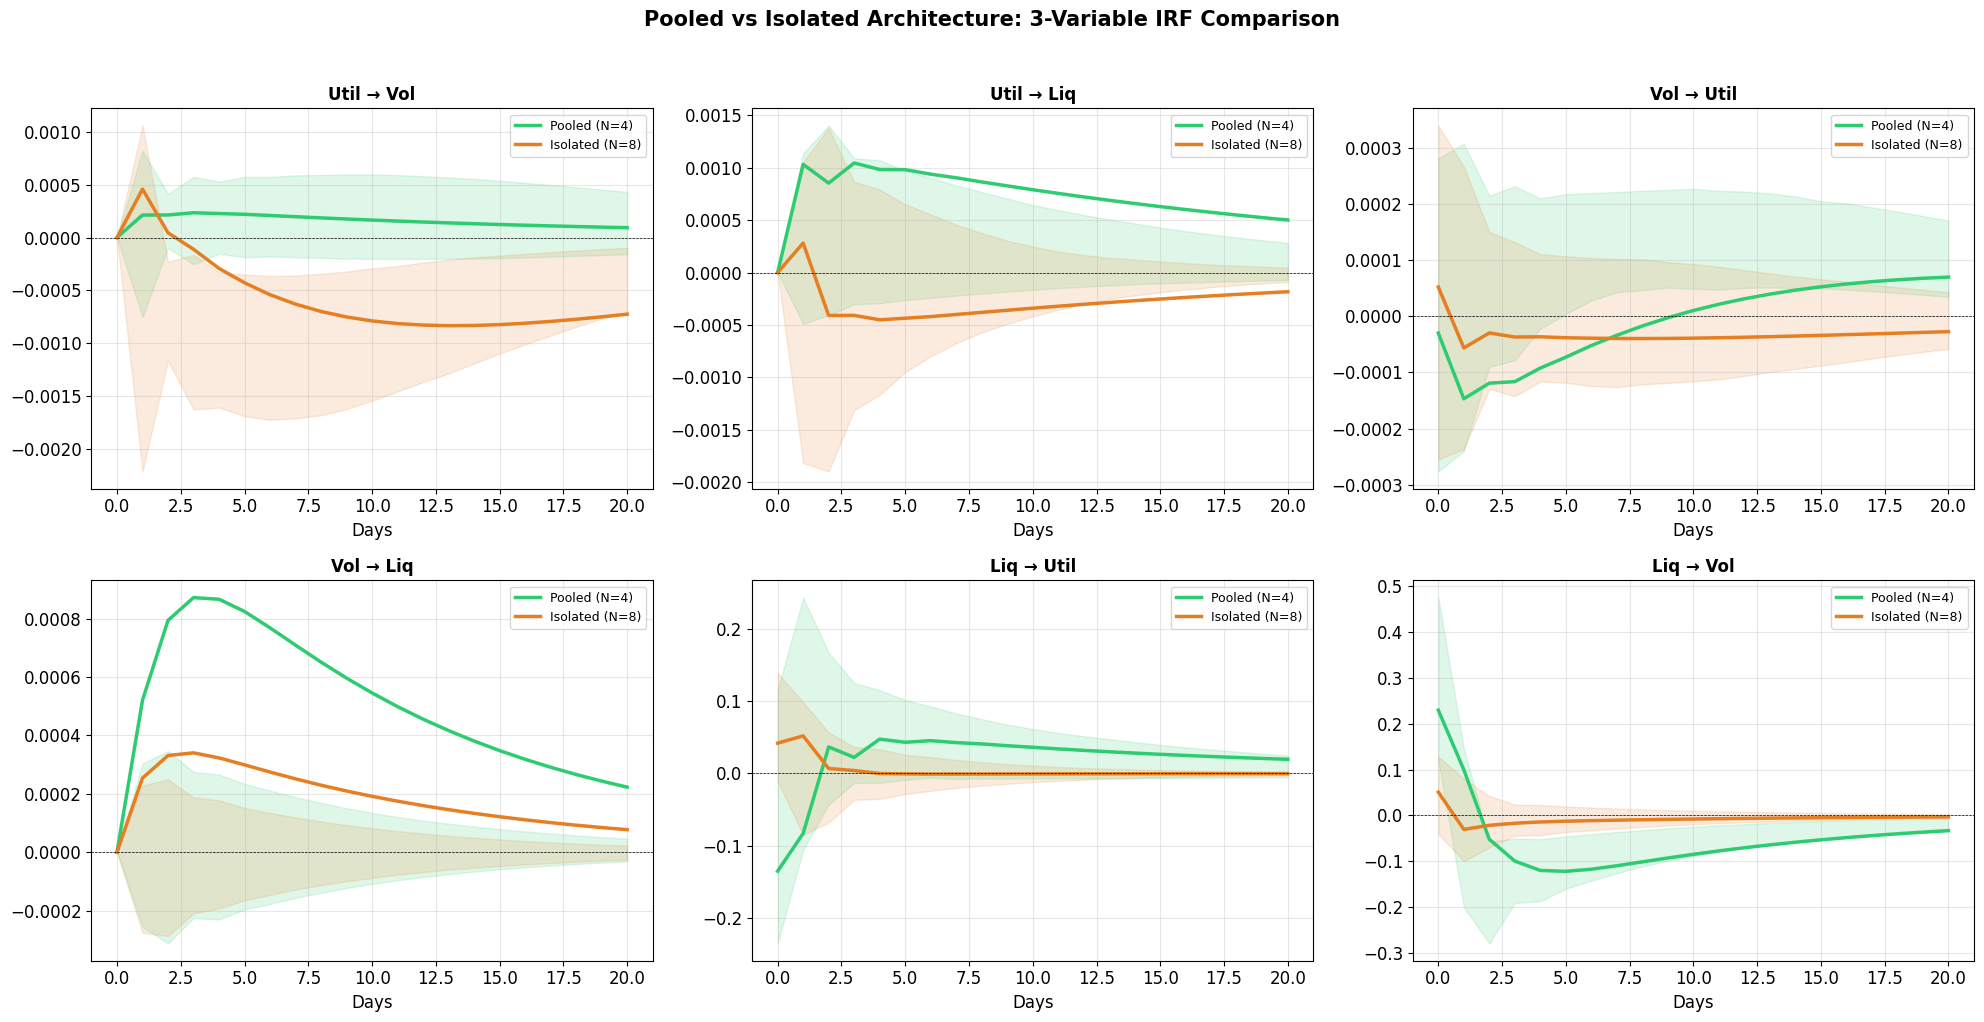

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

arch_colors = {'Pooled': '#2ecc71', 'Isolated': '#e67e22'}

for ax, (imp, resp, title) in zip(axes.flat, cross_irfs):
    for label, color in arch_colors.items():
        res = all_results[label]
        vals = res['irf_orth'][:, imp, resp]
        periods = range(len(vals))
        ax.plot(periods, vals, color=color, lw=2.5, label=f'{label} (N={res["n_csus"]})')
        if res['ci_lo'] is not None:
            ax.fill_between(periods,
                            res['ci_lo'][:, imp, resp],
                            res['ci_hi'][:, imp, resp],
                            alpha=0.15, color=color)
    ax.axhline(0, color='black', ls='--', lw=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Days')
    ax.legend(fontsize=9)

fig.suptitle('Pooled vs Isolated Architecture: 3-Variable IRF Comparison',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/irf_3var_pooled_vs_isolated.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 16. Interpretation Summary

### Variable Definitions
- **Utilization** = Borrowed USD / Supplied USD — a leverage proxy
- **Volatility** = 14-day rolling standard deviation of collateral basket log returns
- **Liquidation** = log(1 + daily collateral seized USD) — captures both extensive (any liquidation) and intensive (how much) margins

### Cholesky Ordering
- **Baseline:** Utilization → Volatility → Liquidation (slow-moving leverage decisions first, then market volatility, then liquidation outcomes)
- **Robustness (Section 17):** Utilization → Liquidation → Volatility (liquidations as mechanical events that feed into volatility)

### Key Questions This Panel VAR Addresses
1. **Does higher utilization predict more liquidations?** (Util→Liq)
2. **Does collateral volatility trigger liquidations?** (Vol→Liq) — the stress channel
3. **Do liquidations cause deleveraging?** (Liq→Util) — the feedback loop
4. **Does the utilization–volatility relationship change when liquidations are controlled for?**
5. **Do Base and Ethereum differ in their liquidation dynamics?**
6. **Do pooled vs isolated architectures respond differently to shocks?**
7. **Are results robust to alternative Cholesky orderings?** (Section 17)

## 17. Robustness Check: Alternative Cholesky Ordering

The baseline ordering is **Utilization → Volatility → Liquidation** (slow to fast).

Here we re-estimate with the alternative ordering **Utilization → Liquidation → Volatility**, which assumes liquidations are protocol-mechanical events that then feed into market volatility, rather than volatility triggering liquidations within the day.

**What changes:** Only the contemporaneous (t=0) restrictions on orthogonalized IRFs and the FEVD allocation of shared variance. Granger causality tests are invariant to ordering.

In [17]:
# Alternative ordering: Utilization → Liquidation → Volatility
ALT_FE_COLS = ['util_fe', 'liq_fe', 'vol_fe']  # swapped liq and vol
ALT_VAR_NAMES = ['Utilization', 'Liquidation', 'Volatility']

def run_panel_var_alt_ordering(df, csus, label, max_lags=10, irf_periods=20, n_boot=500):
    """Re-estimate with alternative Cholesky ordering: util → liq → vol."""
    sub = df[df['csu'].isin(csus)].copy()
    sub = sub.dropna(subset=VAR_COLS)
    
    for orig, fe in zip(VAR_COLS, FE_COLS):
        sub[fe] = sub.groupby('csu')[orig].transform(lambda x: x - x.mean())
    
    # Reorder columns for Cholesky
    panel = sub[ALT_FE_COLS].dropna()
    
    model = VAR(panel)
    try:
        lo = model.select_order(maxlags=min(max_lags, len(panel) // 10))
        optimal = max(1, min(lo.bic, 5))
    except:
        optimal = 2
    
    results = model.fit(optimal)
    irf = results.irf(irf_periods)
    irf_orth = irf.orth_irfs
    
    # Bootstrap CIs
    rng = np.random.RandomState(42)
    boot_irfs = []
    resids = results.resid.values
    fitted = results.fittedvalues.values
    
    for _ in range(n_boot):
        idx = rng.choice(len(resids), size=len(resids), replace=True)
        boot_data = fitted + resids[idx]
        try:
            br = VAR(pd.DataFrame(boot_data, columns=panel.columns)).fit(optimal)
            boot_irfs.append(br.irf(irf_periods).orth_irfs)
        except:
            continue
    
    ci_lo = ci_hi = None
    if len(boot_irfs) > 50:
        ba = np.array(boot_irfs)
        ci_lo = np.percentile(ba, 2.5, axis=0)
        ci_hi = np.percentile(ba, 97.5, axis=0)
    
    return {
        'label': label,
        'results': results,
        'irf_orth': irf_orth,
        'ci_lo': ci_lo,
        'ci_hi': ci_hi,
        'lags': optimal,
    }

# Run alternative ordering for all subsamples
alt_results = {}
for label, csus in samples.items():
    alt_results[label] = run_panel_var_alt_ordering(df_clean, csus, label)
    print(f"  {label}: done (lags={alt_results[label]['lags']})")

print("\nAlternative ordering estimated for all subsamples.")

  Full Sample: done (lags=2)


  Base Chain: done (lags=2)


  Ethereum: done (lags=1)


  Pooled: done (lags=2)


  Isolated: done (lags=2)

Alternative ordering estimated for all subsamples.


### 17a. Compare IRFs: Baseline vs Alternative Ordering

In the alternative ordering, the index mapping is: 0=Utilization, 1=Liquidation, 2=Volatility.
We compare the key cross-variable IRF paths side by side.

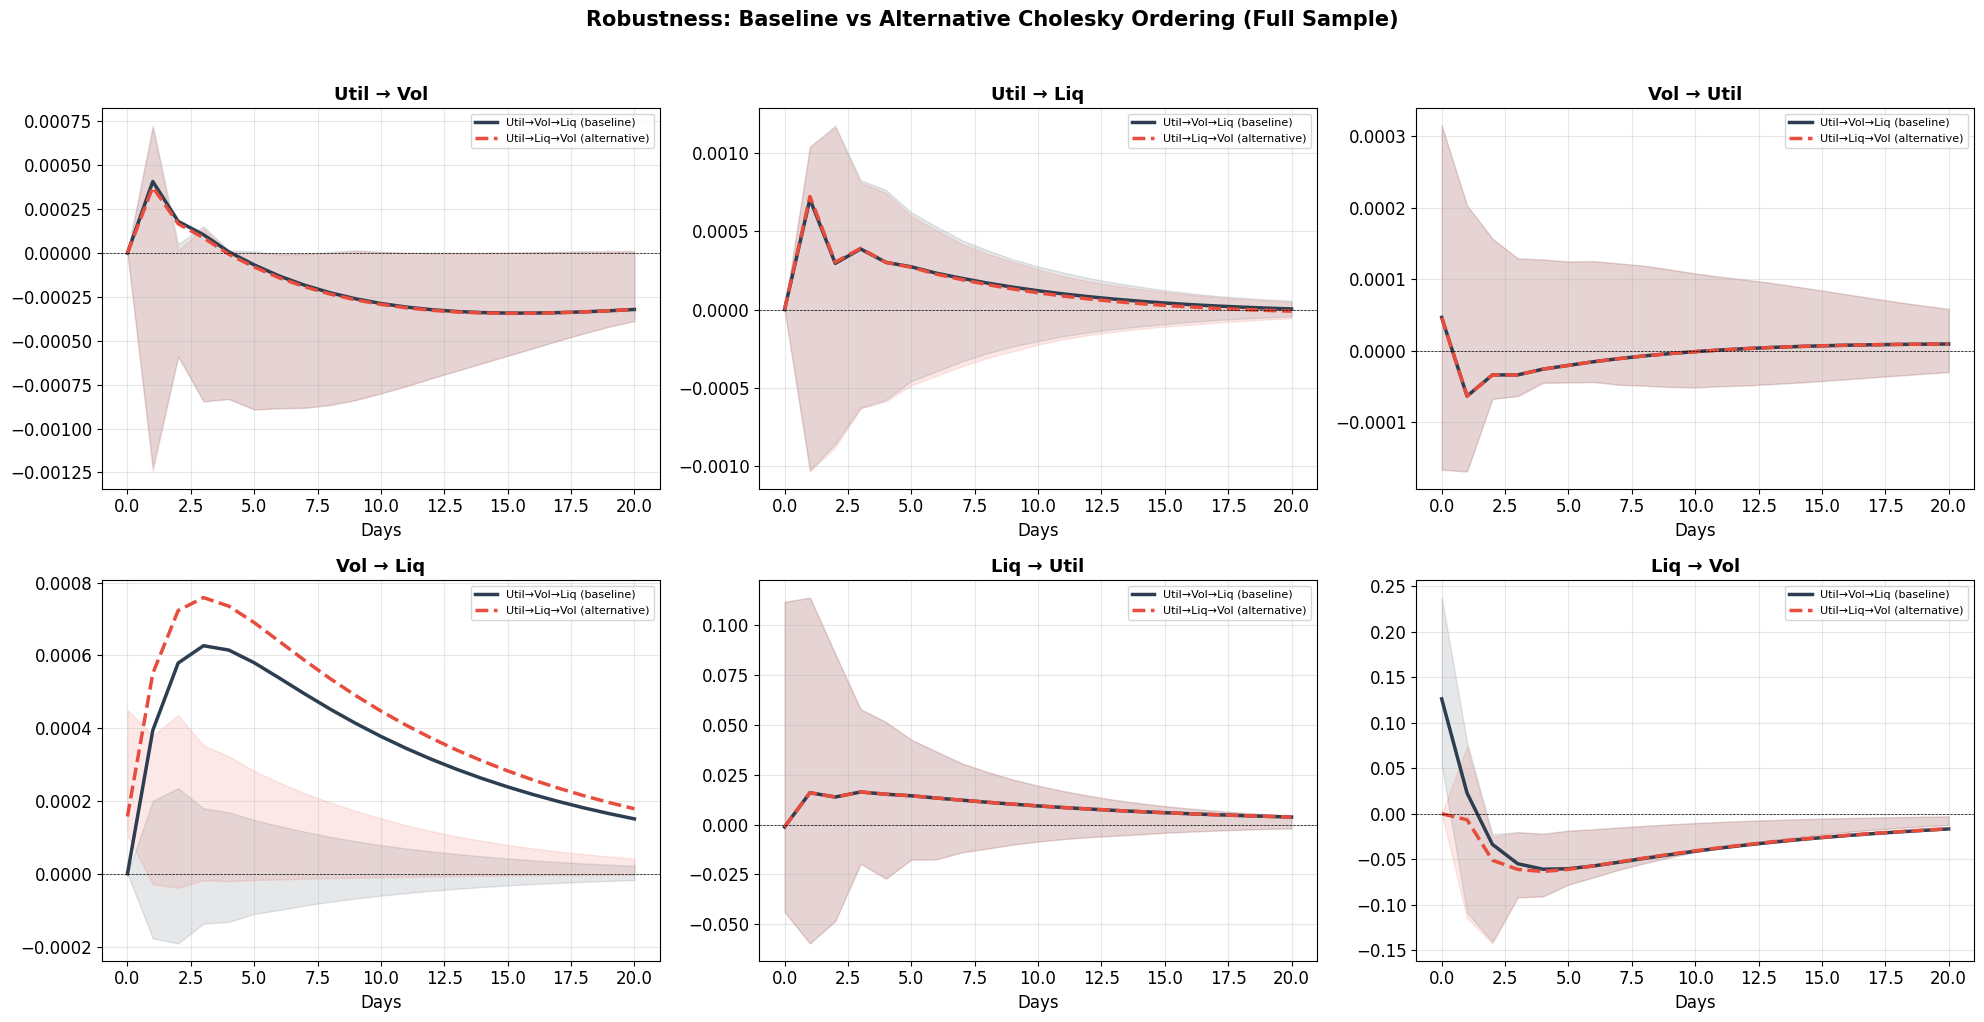

In [18]:
# Map from economic IRF path to (imp_idx, resp_idx) under each ordering
# Baseline: [util=0, vol=1, liq=2]
# Alternative: [util=0, liq=1, vol=2]

path_map = {
    'Util → Vol':  {'baseline': (0, 1), 'alt': (0, 2)},
    'Util → Liq':  {'baseline': (0, 2), 'alt': (0, 1)},
    'Vol → Util':  {'baseline': (1, 0), 'alt': (2, 0)},
    'Vol → Liq':   {'baseline': (1, 2), 'alt': (2, 1)},
    'Liq → Util':  {'baseline': (2, 0), 'alt': (1, 0)},
    'Liq → Vol':   {'baseline': (2, 1), 'alt': (1, 2)},
}

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
path_names = list(path_map.keys())

for ax, pname in zip(axes.flat, path_names):
    bi, bj = path_map[pname]['baseline']
    ai, aj = path_map[pname]['alt']
    
    # Full Sample only
    base_vals = all_results['Full Sample']['irf_orth'][:, bi, bj]
    alt_vals = alt_results['Full Sample']['irf_orth'][:, ai, aj]
    periods = range(len(base_vals))
    
    ax.plot(periods, base_vals, color='#2c3e50', lw=2.5, label='Util→Vol→Liq (baseline)')
    ax.plot(periods, alt_vals, color='#e74c3c', lw=2.5, ls='--', label='Util→Liq→Vol (alternative)')
    
    # CIs for baseline
    res_b = all_results['Full Sample']
    if res_b['ci_lo'] is not None:
        ax.fill_between(periods, res_b['ci_lo'][:, bi, bj], res_b['ci_hi'][:, bi, bj],
                        alpha=0.12, color='#2c3e50')
    # CIs for alt
    res_a = alt_results['Full Sample']
    if res_a['ci_lo'] is not None:
        ax.fill_between(periods, res_a['ci_lo'][:, ai, aj], res_a['ci_hi'][:, ai, aj],
                        alpha=0.12, color='#e74c3c')
    
    ax.axhline(0, color='black', ls='--', lw=0.5)
    ax.set_title(pname, fontsize=13, fontweight='bold')
    ax.set_xlabel('Days')
    ax.legend(fontsize=8)

fig.suptitle('Robustness: Baseline vs Alternative Cholesky Ordering (Full Sample)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/irf_3var_ordering_robustness.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

### 17b. Cumulative IRF Comparison Table

In [19]:
# Compare cumulative IRFs and significance across orderings for all subsamples
print("Table 5: Robustness — Cumulative IRFs by Cholesky Ordering")
print("=" * 120)
print(f"{'Sample':<15} {'IRF Path':<12} {'Baseline Cum':>14} {'Alt Cum':>14} {'Diff':>10} {'Base Sig':>10} {'Alt Sig':>10}")
print("-" * 120)

for label in ['Full Sample', 'Base Chain', 'Ethereum', 'Pooled', 'Isolated']:
    for pname in path_names:
        bi, bj = path_map[pname]['baseline']
        ai, aj = path_map[pname]['alt']
        
        base_vals = all_results[label]['irf_orth'][:, bi, bj]
        alt_vals = alt_results[label]['irf_orth'][:, ai, aj]
        
        base_cum = np.sum(base_vals)
        alt_cum = np.sum(alt_vals)
        diff = alt_cum - base_cum
        
        # Count significant horizons
        def count_sig(res, i, j):
            n = 0
            if res['ci_lo'] is not None:
                for h in range(res['irf_orth'].shape[0]):
                    if res['ci_lo'][h, i, j] > 0 or res['ci_hi'][h, i, j] < 0:
                        n += 1
            return n
        
        base_sig = count_sig(all_results[label], bi, bj)
        alt_sig = count_sig(alt_results[label], ai, aj)
        
        print(f"{label:<15} {pname:<12} {base_cum:>14.5f} {alt_cum:>14.5f} {diff:>10.5f} {base_sig:>7}/21 {alt_sig:>7}/21")
    print()

print("Positive Diff = alternative ordering gives larger cumulative response")
print("Sig Horizons = number of periods where 95% CI excludes zero")

Table 5: Robustness — Cumulative IRFs by Cholesky Ordering
Sample          IRF Path       Baseline Cum        Alt Cum       Diff   Base Sig    Alt Sig
------------------------------------------------------------------------------------------------------------------------
Full Sample     Util → Vol         -0.00377       -0.00391   -0.00014       2/21       6/21
Full Sample     Util → Liq          0.00326        0.00308   -0.00017       0/21       0/21
Full Sample     Vol → Util         -0.00010       -0.00010    0.00000       0/21       0/21
Full Sample     Vol → Liq           0.00743        0.00910    0.00168       0/21       1/21
Full Sample     Liq → Util          0.18915        0.18915   -0.00000       0/21       0/21
Full Sample     Liq → Vol          -0.56577       -0.74324   -0.17747      20/21      19/21

Base Chain      Util → Vol          0.00494        0.00470   -0.00025       0/21       0/21
Base Chain      Util → Liq          0.00622        0.00641    0.00019       0/21   

## 18. Liquidation Mechanism Comparison: Aave-Style (Instant) vs Compound V3 (Absorb)

**Aave-style** protocols allow any third-party liquidator to immediately seize discounted collateral when health factor < 1. This creates a competitive, MEV-driven liquidation market.

**Compound V3 (absorb)** uses a two-step model: the protocol itself absorbs the underwater position, then sells collateral via its own mechanism. This centralizes liquidation execution within the protocol.

We compare the dynamic responses across these two mechanism types using the same 3-variable PVAR framework.

**Cholesky ordering:** Utilization → Liquidation → Volatility

In [20]:
# === Liquidation Mechanism Subsamples ===

aave_style_csus = [
    'aave_v3_ethereum', 'aave_v3_base',
    'moonwell_lending_base', 'sparklend_ethereum',
]

compound_v3_csus = [
    'compound_v3_eth_usdc', 'compound_v3_eth_usdt', 'compound_v3_eth_usds',
    'compound_v3_eth_weth', 'compound_v3_eth_wsteth',
    'compound_v3_base_usdc', 'compound_v3_base_weth', 'compound_v3_base_aero',
]

# Filter to CSUs present in clean data
aave_style_csus = [c for c in aave_style_csus if c in valid]
compound_v3_csus = [c for c in compound_v3_csus if c in valid]

mech_samples = {
    'Aave-Style (Instant)': aave_style_csus,
    'Compound V3 (Absorb)': compound_v3_csus,
    'Full Sample': base_csus + eth_csus,
}

print("Liquidation Mechanism Subsamples:")
print("-" * 60)
for label, csus in mech_samples.items():
    sub = df_clean[df_clean['csu'].isin(csus)]
    n_liq = sub['n_liquidations'].sum()
    print(f"  {label}: {len(csus)} CSUs, {len(sub):,} obs, {n_liq:,} liq events")
    for c in csus:
        n = df_clean[df_clean['csu'] == c]['n_liquidations'].sum()
        print(f"    {c}: {n:,} events")

Liquidation Mechanism Subsamples:
------------------------------------------------------------
  Aave-Style (Instant): 4 CSUs, 1,456 obs, 11,272 liq events
    aave_v3_ethereum: 5,093 events
    aave_v3_base: 5,715 events
    moonwell_lending_base: 0 events
    sparklend_ethereum: 464 events
  Compound V3 (Absorb): 8 CSUs, 1,818 obs, 1,750 liq events
    compound_v3_eth_usdc: 733 events
    compound_v3_eth_usdt: 50 events
    compound_v3_eth_usds: 1 events
    compound_v3_eth_weth: 1 events
    compound_v3_eth_wsteth: 0 events
    compound_v3_base_usdc: 949 events
    compound_v3_base_weth: 14 events
    compound_v3_base_aero: 2 events
  Full Sample: 12 CSUs, 3,274 obs, 13,022 liq events
    aave_v3_base: 5,715 events
    compound_v3_base_aero: 2 events
    compound_v3_base_usdc: 949 events
    compound_v3_base_weth: 14 events
    moonwell_lending_base: 0 events
    aave_v3_ethereum: 5,093 events
    compound_v3_eth_usdc: 733 events
    compound_v3_eth_usds: 1 events
    compound_v3_et

### 18a. Summary Statistics by Mechanism

In [21]:
mech_stats = []
for label, csus in mech_samples.items():
    sub = df_clean[df_clean['csu'].isin(csus)]
    mech_stats.append({
        'Mechanism': label,
        'N (CSUs)': sub['csu'].nunique(),
        'T (dates)': sub['date'].nunique(),
        'Obs': len(sub),
        'Util Mean': sub['utilization'].mean(),
        'Util SD': sub['utilization'].std(),
        'Vol Mean': sub['volatility'].mean(),
        'Vol SD': sub['volatility'].std(),
        'Liq/Day Mean': sub['n_liquidations'].mean(),
        'Liq/Day SD': sub['n_liquidations'].std(),
        '% Days w/ Liq': 100 * sub['has_liquidation'].mean(),
        'Avg Coll USD': sub.loc[sub['n_liquidations'] > 0, 'total_collateral_usd'].mean(),
    })

mech_stats_df = pd.DataFrame(mech_stats)
print("Table 6: Summary Statistics by Liquidation Mechanism")
print("=" * 110)
print(mech_stats_df.to_string(index=False, float_format=lambda x: f"{x:.4f}" if abs(x) < 1 else f"{x:,.1f}"))

Table 6: Summary Statistics by Liquidation Mechanism
           Mechanism  N (CSUs)  T (dates)  Obs  Util Mean  Util SD  Vol Mean  Vol SD  Liq/Day Mean  Liq/Day SD  % Days w/ Liq  Avg Coll USD
Aave-Style (Instant)         4        364 1456     0.4493   0.0985    0.0214  0.0093           7.7        59.3           45.3     921,977.5
Compound V3 (Absorb)         8        364 1818     0.3131   0.0786    0.0232  0.0117        0.9626        16.8            6.4   1,141,006.5
         Full Sample        12        364 3274     0.3737   0.1110    0.0224  0.0108           4.0        41.6           23.7     954,958.7


### 18b. Estimate Panel VAR by Mechanism

Using the **alternative Cholesky ordering**: Utilization → Liquidation → Volatility (as requested).

In [22]:
# Use ordering: util → liq → vol
MECH_FE_COLS = ['util_fe', 'liq_fe', 'vol_fe']
MECH_VAR_NAMES = ['Utilization', 'Liquidation', 'Volatility']
# Index map: 0=util, 1=liq, 2=vol

mech_results = {}
for label, csus in mech_samples.items():
    print(f"\n{'='*60}")
    print(f"  {label} ({len(csus)} CSUs)")
    print(f"{'='*60}")
    
    sub = df_clean[df_clean['csu'].isin(csus)].copy()
    sub = sub.dropna(subset=VAR_COLS)
    
    for orig, fe in zip(VAR_COLS, FE_COLS):
        sub[fe] = sub.groupby('csu')[orig].transform(lambda x: x - x.mean())
    
    panel = sub[MECH_FE_COLS].dropna()
    print(f"  Panel: {len(panel):,} obs after FE transform")
    
    model = VAR(panel)
    try:
        lo = model.select_order(maxlags=min(10, len(panel) // 10))
        optimal = max(1, min(lo.bic, 5))
        print(f"  Lag selection — AIC: {lo.aic}, BIC: {lo.bic}, HQIC: {lo.hqic} → using {optimal}")
    except:
        optimal = 2
        print(f"  Lag selection failed, using {optimal}")
    
    results = model.fit(optimal)
    irf = results.irf(20)
    irf_orth = irf.orth_irfs
    
    # Bootstrap
    rng = np.random.RandomState(42)
    boot_irfs = []
    resids = results.resid.values
    fitted = results.fittedvalues.values
    
    for _ in range(500):
        idx = rng.choice(len(resids), size=len(resids), replace=True)
        boot_data = fitted + resids[idx]
        try:
            br = VAR(pd.DataFrame(boot_data, columns=panel.columns)).fit(optimal)
            boot_irfs.append(br.irf(20).orth_irfs)
        except:
            continue
    
    ci_lo = ci_hi = None
    if len(boot_irfs) > 50:
        ba = np.array(boot_irfs)
        ci_lo = np.percentile(ba, 2.5, axis=0)
        ci_hi = np.percentile(ba, 97.5, axis=0)
        print(f"  Bootstrap: {len(boot_irfs)}/500 successful replications")
    
    # Granger causality — all 6 directions
    gc = {}
    pairs = [
        ('util_fe', 'liq_fe',  'Util→Liq'),
        ('liq_fe',  'util_fe', 'Liq→Util'),
        ('util_fe', 'vol_fe',  'Util→Vol'),
        ('vol_fe',  'util_fe', 'Vol→Util'),
        ('liq_fe',  'vol_fe',  'Liq→Vol'),
        ('vol_fe',  'liq_fe',  'Vol→Liq'),
    ]
    for cause, effect, name in pairs:
        try:
            test = results.test_causality(effect, [cause], kind='f')
            gc[name] = {'F': test.test_statistic, 'p': test.pvalue}
        except:
            pass
    
    mech_results[label] = {
        'label': label,
        'results': results,
        'irf_orth': irf_orth,
        'ci_lo': ci_lo,
        'ci_hi': ci_hi,
        'gc': gc,
        'n_csus': sub['csu'].nunique(),
        'n_obs': len(sub),
        'lags': optimal,
    }


  Aave-Style (Instant) (4 CSUs)
  Panel: 1,456 obs after FE transform
  Lag selection — AIC: 10, BIC: 2, HQIC: 2 → using 2


  Bootstrap: 500/500 successful replications

  Compound V3 (Absorb) (8 CSUs)
  Panel: 1,818 obs after FE transform
  Lag selection — AIC: 9, BIC: 2, HQIC: 2 → using 2


  Bootstrap: 500/500 successful replications

  Full Sample (12 CSUs)
  Panel: 3,274 obs after FE transform
  Lag selection — AIC: 10, BIC: 2, HQIC: 2 → using 2


  Bootstrap: 500/500 successful replications


### 18c. Granger Causality — Mechanism Comparison

In [23]:
gc_dirs = ['Util→Liq', 'Liq→Util', 'Util→Vol', 'Vol→Util', 'Liq→Vol', 'Vol→Liq']

gc_mech_rows = []
for label, res in mech_results.items():
    row = {'Mechanism': label, 'N': res['n_csus'], 'Obs': f"{res['n_obs']:,}", 'Lags': res['lags']}
    for d in gc_dirs:
        if d in res['gc']:
            f_val = res['gc'][d]['F']
            p_val = res['gc'][d]['p']
            row[f'F({d})'] = f'{f_val:.3f}'
            row[f'p({d})'] = f'{p_val:.4f}{stars(p_val)}'
        else:
            row[f'F({d})'] = '—'
            row[f'p({d})'] = '—'
    gc_mech_rows.append(row)

gc_mech_df = pd.DataFrame(gc_mech_rows)
print("Table 7: Granger Causality — Liquidation Mechanism Comparison")
print("=" * 140)
print(gc_mech_df.to_string(index=False))
print("\n*** p<0.01, ** p<0.05, * p<0.10")
print("\nOrdering: Utilization → Liquidation → Volatility")

Table 7: Granger Causality — Liquidation Mechanism Comparison
           Mechanism  N   Obs  Lags F(Util→Liq) p(Util→Liq) F(Liq→Util) p(Liq→Util) F(Util→Vol) p(Util→Vol) F(Vol→Util) p(Vol→Util) F(Liq→Vol) p(Liq→Vol) F(Vol→Liq) p(Vol→Liq)
Aave-Style (Instant)  4 1,456     2       1.161      0.3132       5.708   0.0033***       0.814      0.4431       0.200      0.8186     24.633  0.0000***      4.736  0.0088***
Compound V3 (Absorb)  8 1,818     2       0.376      0.6864       0.656      0.5188       0.881      0.4142       0.843      0.4305      4.726  0.0089***      0.655     0.5193
         Full Sample 12 3,274     2       0.232      0.7933       1.846      0.1579       1.711      0.1807       0.735      0.4794     26.179  0.0000***      3.698   0.0248**

*** p<0.01, ** p<0.05, * p<0.10

Ordering: Utilization → Liquidation → Volatility


### 18d. IRF Plots — Aave-Style vs Compound V3

Key cross-variable paths: Util→Liq, Liq→Vol, Util→Vol (plus their reverses).

Index mapping for ordering [util, liq, vol]: Util=0, Liq=1, Vol=2.

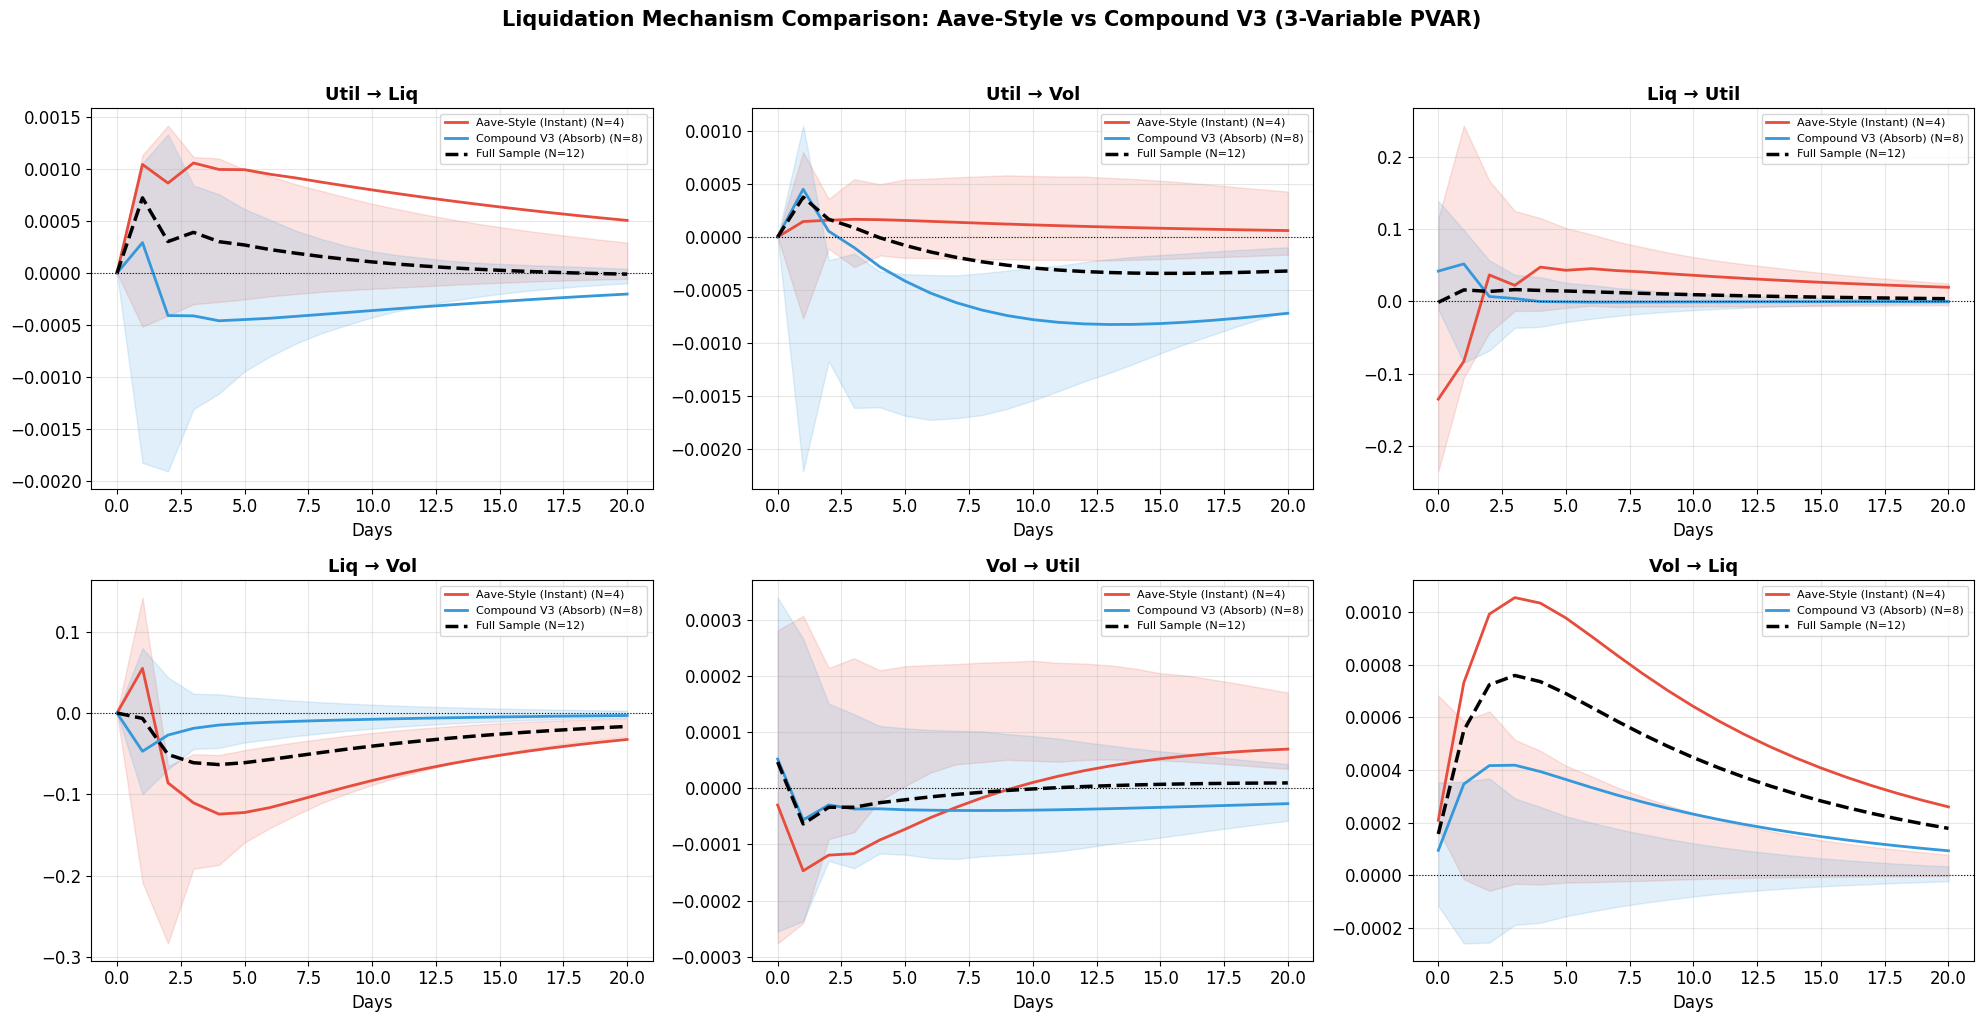

In [24]:
# Cross-variable IRFs under ordering [util=0, liq=1, vol=2]
mech_cross_irfs = [
    (0, 1, 'Util → Liq'),
    (0, 2, 'Util → Vol'),
    (1, 0, 'Liq → Util'),
    (1, 2, 'Liq → Vol'),
    (2, 0, 'Vol → Util'),
    (2, 1, 'Vol → Liq'),
]

mech_colors = {
    'Aave-Style (Instant)': '#e74c3c',
    'Compound V3 (Absorb)': '#3498db',
    'Full Sample': 'black',
}

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for ax, (imp, resp, title) in zip(axes.flat, mech_cross_irfs):
    for label, color in mech_colors.items():
        res = mech_results[label]
        vals = res['irf_orth'][:, imp, resp]
        periods = range(len(vals))
        lw = 2.5 if label == 'Full Sample' else 2.0
        ls = '-' if label != 'Full Sample' else '--'
        ax.plot(periods, vals, color=color, lw=lw, ls=ls,
                label=f'{label} (N={res["n_csus"]})')
        if res['ci_lo'] is not None and label != 'Full Sample':
            ax.fill_between(periods,
                            res['ci_lo'][:, imp, resp],
                            res['ci_hi'][:, imp, resp],
                            alpha=0.15, color=color)
    ax.axhline(0, color='black', ls=':', lw=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Days')
    ax.legend(fontsize=8)

fig.suptitle('Liquidation Mechanism Comparison: Aave-Style vs Compound V3 (3-Variable PVAR)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/irf_3var_mechanism_comparison.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

### 18e. IRF Summary Table — Mechanism Comparison

In [25]:
mech_irf_rows = []
for label, res in mech_results.items():
    for imp, resp, name in mech_cross_irfs:
        vals = res['irf_orth'][:, imp, resp]
        peak_idx = int(np.argmax(np.abs(vals)))
        cumul = np.sum(vals)
        
        n_sig = 0
        if res['ci_lo'] is not None:
            for h in range(len(vals)):
                lo = res['ci_lo'][h, imp, resp]
                hi = res['ci_hi'][h, imp, resp]
                if lo > 0 or hi < 0:
                    n_sig += 1
        
        mech_irf_rows.append({
            'Mechanism': label,
            'IRF Path': name,
            'Impact (t=1)': f'{vals[1]:.5f}',
            'Peak': f'{vals[peak_idx]:.5f}',
            'Peak Period': f't+{peak_idx}',
            'Cumulative': f'{cumul:.5f}',
            'Sign': '+' if cumul > 0 else '−',
            'Sig Horizons': f'{n_sig}/21',
        })

mech_irf_df = pd.DataFrame(mech_irf_rows)
print("Table 8: IRF Summary — Liquidation Mechanism Comparison")
print("=" * 110)
for label in mech_results:
    sub = mech_irf_df[mech_irf_df['Mechanism'] == label]
    print(f"\n--- {label} (N={mech_results[label]['n_csus']}, {mech_results[label]['n_obs']:,} obs, {mech_results[label]['lags']} lags) ---")
    print(sub.drop(columns='Mechanism').to_string(index=False))

Table 8: IRF Summary — Liquidation Mechanism Comparison

--- Aave-Style (Instant) (N=4, 1,456 obs, 2 lags) ---
  IRF Path Impact (t=1)     Peak Peak Period Cumulative Sign Sig Horizons
Util → Liq      0.00104  0.00106         t+3    0.01559    +         0/21
Util → Vol      0.00015  0.00017         t+3    0.00226    +         0/21
Liq → Util     -0.08274 -0.13486         t+0    0.39468    +         0/21
 Liq → Vol      0.05495 -0.12432         t+4   -1.39998    −        19/21
Vol → Util     -0.00015 -0.00015         t+1   -0.00016    −        16/21
 Vol → Liq      0.00073  0.00105         t+3    0.01288    +         1/21

--- Compound V3 (Absorb) (N=8, 1,818 obs, 2 lags) ---
  IRF Path Impact (t=1)     Peak Peak Period Cumulative Sign Sig Horizons
Util → Liq      0.00029 -0.00046         t+4   -0.00610    −         0/21
Util → Vol      0.00045 -0.00083        t+13   -0.01157    −        19/21
Liq → Util      0.05179  0.05179         t+1    0.09588    +         0/21
 Liq → Vol     -0.04

## 19. Export Results

Save all tables and key data to the `results/` directory for use in the thesis.

In [26]:
import os
results_dir = '../results'
os.makedirs(results_dir, exist_ok=True)

# --- Table 1: Panel Summary Statistics ---
summary_df.to_csv(f'{results_dir}/table1_panel_summary_stats.csv', index=False)

# --- Table 2: Granger Causality (baseline ordering) ---
gc_df.to_csv(f'{results_dir}/table2_granger_causality_baseline.csv', index=False)

# --- Table 3: IRF Summary (baseline ordering) ---
irf_df.to_csv(f'{results_dir}/table3_irf_summary_baseline.csv', index=False)

# --- Table 4: Architecture & Chain Comparison ---
comp_df.to_csv(f'{results_dir}/table4_architecture_comparison.csv', index=False)

# --- Table 5: Robustness — Ordering Comparison ---
robust_rows = []
for label in ['Full Sample', 'Base Chain', 'Ethereum', 'Pooled', 'Isolated']:
    for pname in path_names:
        bi, bj = path_map[pname]['baseline']
        ai, aj = path_map[pname]['alt']
        base_vals = all_results[label]['irf_orth'][:, bi, bj]
        alt_vals = alt_results[label]['irf_orth'][:, ai, aj]
        
        def count_sig(res, i, j):
            n = 0
            if res['ci_lo'] is not None:
                for h in range(res['irf_orth'].shape[0]):
                    if res['ci_lo'][h, i, j] > 0 or res['ci_hi'][h, i, j] < 0:
                        n += 1
            return n
        
        robust_rows.append({
            'Sample': label,
            'IRF Path': pname,
            'Baseline Cumulative': np.sum(base_vals),
            'Alt Cumulative': np.sum(alt_vals),
            'Diff': np.sum(alt_vals) - np.sum(base_vals),
            'Baseline Sig Horizons': count_sig(all_results[label], bi, bj),
            'Alt Sig Horizons': count_sig(alt_results[label], ai, aj),
        })
pd.DataFrame(robust_rows).to_csv(f'{results_dir}/table5_robustness_ordering.csv', index=False)

# --- Table 6: Mechanism Summary Statistics ---
mech_stats_df.to_csv(f'{results_dir}/table6_mechanism_summary_stats.csv', index=False)

# --- Table 7: Mechanism Granger Causality ---
gc_mech_df.to_csv(f'{results_dir}/table7_mechanism_granger_causality.csv', index=False)

# --- Table 8: Mechanism IRF Summary ---
mech_irf_df.to_csv(f'{results_dir}/table8_mechanism_irf_summary.csv', index=False)

# --- IRF point estimates for all mechanism subsamples (for detailed analysis) ---
mech_irf_detail = []
for label, res in mech_results.items():
    for imp, resp, name in mech_cross_irfs:
        vals = res['irf_orth'][:, imp, resp]
        for h in range(len(vals)):
            row = {'Mechanism': label, 'IRF Path': name, 'Horizon': h, 'IRF': vals[h]}
            if res['ci_lo'] is not None:
                row['CI_lo'] = res['ci_lo'][h, imp, resp]
                row['CI_hi'] = res['ci_hi'][h, imp, resp]
                row['Significant'] = (row['CI_lo'] > 0) or (row['CI_hi'] < 0)
            mech_irf_detail.append(row)
pd.DataFrame(mech_irf_detail).to_csv(f'{results_dir}/mechanism_irf_point_estimates.csv', index=False)

# List saved files
saved = [f for f in sorted(os.listdir(results_dir)) if f.startswith('table') or f.startswith('mech') or f.startswith('irf_3var')]
print("Results exported to ../results/:")
print("-" * 60)
for f in saved:
    size = os.path.getsize(f'{results_dir}/{f}')
    print(f"  {f} ({size:,} bytes)")

Results exported to ../results/:
------------------------------------------------------------
  irf_3var_base_vs_eth.png (366,712 bytes)
  irf_3var_cross_comparison.png (676,149 bytes)
  irf_3var_full_grid.png (578,416 bytes)
  irf_3var_mechanism_comparison.png (672,597 bytes)
  irf_3var_ordering_robustness.png (583,895 bytes)
  irf_3var_pooled_vs_isolated.png (586,807 bytes)
  mechanism_irf_point_estimates.csv (39,560 bytes)
  table1_panel_summary_stats.csv (981 bytes)
  table1_summary_stats.png (104,001 bytes)
  table1_summary_stats.tex (490 bytes)
  table2_granger_causality.png (105,282 bytes)
  table2_granger_causality.tex (441 bytes)
  table2_granger_causality_baseline.csv (666 bytes)
  table3_irf_summary.png (133,193 bytes)
  table3_irf_summary.tex (546 bytes)
  table3_irf_summary_baseline.csv (1,857 bytes)
  table4_architecture_comparison.csv (503 bytes)
  table4_architecture_comparison.png (152,757 bytes)
  table4_architecture_comparison.tex (618 bytes)
  table5_robustness_orde

## 20. Chain Comparison: Ethereum (L1) vs Base (L2)

Ethereum is a Layer-1 chain with higher gas costs and deeper liquidity. Base is a Layer-2 rollup with lower fees and newer markets. We compare the dynamic responses to test whether settlement layer characteristics affect the utilization–volatility–liquidation feedback loop.

**Cholesky ordering:** Utilization → Liquidation → Volatility

In [27]:
# === Chain Subsamples ===

ethereum_l1_csus = [
    'aave_v3_ethereum', 'compound_v3_eth_usdc', 'compound_v3_eth_usdt',
    'compound_v3_eth_usds', 'compound_v3_eth_weth', 'compound_v3_eth_wsteth',
    'sparklend_ethereum',
]

base_l2_csus = [
    'aave_v3_base', 'compound_v3_base_usdc', 'compound_v3_base_weth',
    'compound_v3_base_aero', 'moonwell_lending_base',
]

# Filter to CSUs present in clean data
ethereum_l1_csus = [c for c in ethereum_l1_csus if c in valid]
base_l2_csus = [c for c in base_l2_csus if c in valid]

chain_samples = {
    'Ethereum (L1)': ethereum_l1_csus,
    'Base (L2)': base_l2_csus,
    'Full Sample': base_csus + eth_csus,
}

print("Chain Subsamples:")
print("-" * 60)
for label, csus in chain_samples.items():
    sub = df_clean[df_clean['csu'].isin(csus)]
    n_liq = sub['n_liquidations'].sum()
    print(f"  {label}: {len(csus)} CSUs, {len(sub):,} obs, {n_liq:,} liq events")
    for c in csus:
        n = df_clean[df_clean['csu'] == c]['n_liquidations'].sum()
        print(f"    {c}: {n:,} events")

Chain Subsamples:
------------------------------------------------------------
  Ethereum (L1): 7 CSUs, 1,815 obs, 6,342 liq events
    aave_v3_ethereum: 5,093 events
    compound_v3_eth_usdc: 733 events
    compound_v3_eth_usdt: 50 events
    compound_v3_eth_usds: 1 events
    compound_v3_eth_weth: 1 events
    compound_v3_eth_wsteth: 0 events
    sparklend_ethereum: 464 events
  Base (L2): 5 CSUs, 1,459 obs, 6,680 liq events
    aave_v3_base: 5,715 events
    compound_v3_base_usdc: 949 events
    compound_v3_base_weth: 14 events
    compound_v3_base_aero: 2 events
    moonwell_lending_base: 0 events
  Full Sample: 12 CSUs, 3,274 obs, 13,022 liq events
    aave_v3_base: 5,715 events
    compound_v3_base_aero: 2 events
    compound_v3_base_usdc: 949 events
    compound_v3_base_weth: 14 events
    moonwell_lending_base: 0 events
    aave_v3_ethereum: 5,093 events
    compound_v3_eth_usdc: 733 events
    compound_v3_eth_usds: 1 events
    compound_v3_eth_usdt: 50 events
    compound_v3_e

### 20a. Summary Statistics by Chain

In [28]:
chain_stats = []
for label, csus in chain_samples.items():
    sub = df_clean[df_clean['csu'].isin(csus)]
    chain_stats.append({
        'Chain': label,
        'N (CSUs)': sub['csu'].nunique(),
        'T (dates)': sub['date'].nunique(),
        'Obs': len(sub),
        'Util Mean': sub['utilization'].mean(),
        'Util SD': sub['utilization'].std(),
        'Vol Mean': sub['volatility'].mean(),
        'Vol SD': sub['volatility'].std(),
        'Liq/Day Mean': sub['n_liquidations'].mean(),
        'Liq/Day SD': sub['n_liquidations'].std(),
        '% Days w/ Liq': 100 * sub['has_liquidation'].mean(),
        'Avg Coll USD': sub.loc[sub['n_liquidations'] > 0, 'total_collateral_usd'].mean(),
    })

chain_stats_df = pd.DataFrame(chain_stats)
print("Table 9: Summary Statistics by Chain")
print("=" * 110)
print(chain_stats_df.to_string(index=False, float_format=lambda x: f"{x:.4f}" if abs(x) < 1 else f"{x:,.1f}"))

Table 9: Summary Statistics by Chain
        Chain  N (CSUs)  T (dates)  Obs  Util Mean  Util SD  Vol Mean  Vol SD  Liq/Day Mean  Liq/Day SD  % Days w/ Liq  Avg Coll USD
Ethereum (L1)         7        364 1815     0.3350   0.0710    0.0214  0.0102           3.5        40.2           25.1   1,606,789.5
    Base (L2)         5        364 1459     0.4218   0.1312    0.0237  0.0113           4.6        43.3           22.0      28,993.6
  Full Sample        12        364 3274     0.3737   0.1110    0.0224  0.0108           4.0        41.6           23.7     954,958.7


### 20b. Estimate Panel VAR by Chain

Cholesky ordering: Utilization → Liquidation → Volatility

In [29]:
# Ordering: util → liq → vol (same as mechanism comparison)
CHAIN_FE_COLS = ['util_fe', 'liq_fe', 'vol_fe']
# Index map: 0=util, 1=liq, 2=vol

chain_results = {}
for label, csus in chain_samples.items():
    print(f"\n{'='*60}")
    print(f"  {label} ({len(csus)} CSUs)")
    print(f"{'='*60}")
    
    sub = df_clean[df_clean['csu'].isin(csus)].copy()
    sub = sub.dropna(subset=VAR_COLS)
    
    for orig, fe in zip(VAR_COLS, FE_COLS):
        sub[fe] = sub.groupby('csu')[orig].transform(lambda x: x - x.mean())
    
    panel = sub[CHAIN_FE_COLS].dropna()
    print(f"  Panel: {len(panel):,} obs after FE transform")
    
    model = VAR(panel)
    try:
        lo = model.select_order(maxlags=min(10, len(panel) // 10))
        optimal = max(1, min(lo.bic, 5))
        print(f"  Lag selection — AIC: {lo.aic}, BIC: {lo.bic}, HQIC: {lo.hqic} → using {optimal}")
    except:
        optimal = 2
        print(f"  Lag selection failed, using {optimal}")
    
    results = model.fit(optimal)
    irf = results.irf(20)
    irf_orth = irf.orth_irfs
    
    # Bootstrap
    rng = np.random.RandomState(42)
    boot_irfs = []
    resids = results.resid.values
    fitted = results.fittedvalues.values
    
    for _ in range(500):
        idx = rng.choice(len(resids), size=len(resids), replace=True)
        boot_data = fitted + resids[idx]
        try:
            br = VAR(pd.DataFrame(boot_data, columns=panel.columns)).fit(optimal)
            boot_irfs.append(br.irf(20).orth_irfs)
        except:
            continue
    
    ci_lo = ci_hi = None
    if len(boot_irfs) > 50:
        ba = np.array(boot_irfs)
        ci_lo = np.percentile(ba, 2.5, axis=0)
        ci_hi = np.percentile(ba, 97.5, axis=0)
        print(f"  Bootstrap: {len(boot_irfs)}/500 successful replications")
    
    # Granger causality — all 6 directions
    gc = {}
    pairs = [
        ('util_fe', 'liq_fe',  'Util→Liq'),
        ('liq_fe',  'util_fe', 'Liq→Util'),
        ('util_fe', 'vol_fe',  'Util→Vol'),
        ('vol_fe',  'util_fe', 'Vol→Util'),
        ('liq_fe',  'vol_fe',  'Liq→Vol'),
        ('vol_fe',  'liq_fe',  'Vol→Liq'),
    ]
    for cause, effect, name in pairs:
        try:
            test = results.test_causality(effect, [cause], kind='f')
            gc[name] = {'F': test.test_statistic, 'p': test.pvalue}
        except:
            pass
    
    chain_results[label] = {
        'label': label,
        'results': results,
        'irf_orth': irf_orth,
        'ci_lo': ci_lo,
        'ci_hi': ci_hi,
        'gc': gc,
        'n_csus': sub['csu'].nunique(),
        'n_obs': len(sub),
        'lags': optimal,
    }


  Ethereum (L1) (7 CSUs)
  Panel: 1,815 obs after FE transform
  Lag selection — AIC: 10, BIC: 1, HQIC: 1 → using 1


  Bootstrap: 500/500 successful replications

  Base (L2) (5 CSUs)
  Panel: 1,459 obs after FE transform
  Lag selection — AIC: 10, BIC: 2, HQIC: 3 → using 2


  Bootstrap: 500/500 successful replications

  Full Sample (12 CSUs)
  Panel: 3,274 obs after FE transform
  Lag selection — AIC: 10, BIC: 2, HQIC: 2 → using 2


  Bootstrap: 500/500 successful replications


### 20c. Granger Causality — Chain Comparison

In [30]:
gc_chain_rows = []
for label, res in chain_results.items():
    row = {'Chain': label, 'N': res['n_csus'], 'Obs': f"{res['n_obs']:,}", 'Lags': res['lags']}
    for d in gc_dirs:
        if d in res['gc']:
            f_val = res['gc'][d]['F']
            p_val = res['gc'][d]['p']
            row[f'F({d})'] = f'{f_val:.3f}'
            row[f'p({d})'] = f'{p_val:.4f}{stars(p_val)}'
        else:
            row[f'F({d})'] = '—'
            row[f'p({d})'] = '—'
    gc_chain_rows.append(row)

gc_chain_df = pd.DataFrame(gc_chain_rows)
print("Table 10: Granger Causality — Chain Comparison")
print("=" * 140)
print(gc_chain_df.to_string(index=False))
print("\n*** p<0.01, ** p<0.05, * p<0.10")
print("\nOrdering: Utilization → Liquidation → Volatility")

Table 10: Granger Causality — Chain Comparison
        Chain  N   Obs  Lags F(Util→Liq) p(Util→Liq) F(Liq→Util) p(Liq→Util) F(Util→Vol) p(Util→Vol) F(Vol→Util) p(Vol→Util) F(Liq→Vol) p(Liq→Vol) F(Vol→Liq) p(Vol→Liq)
Ethereum (L1)  7 1,815     1       0.070      0.7917       3.230     0.0724*       0.004      0.9524       0.821      0.3649     44.598  0.0000***      5.390   0.0203**
    Base (L2)  5 1,459     2       0.525      0.5918       0.183      0.8326       0.373      0.6890       0.235      0.7902      8.773  0.0002***      1.805     0.1645
  Full Sample 12 3,274     2       0.232      0.7933       1.846      0.1579       1.711      0.1807       0.735      0.4794     26.179  0.0000***      3.698   0.0248**

*** p<0.01, ** p<0.05, * p<0.10

Ordering: Utilization → Liquidation → Volatility


### 20d. IRF Plots — Ethereum (L1) vs Base (L2)

Index mapping for ordering [util, liq, vol]: Util=0, Liq=1, Vol=2.

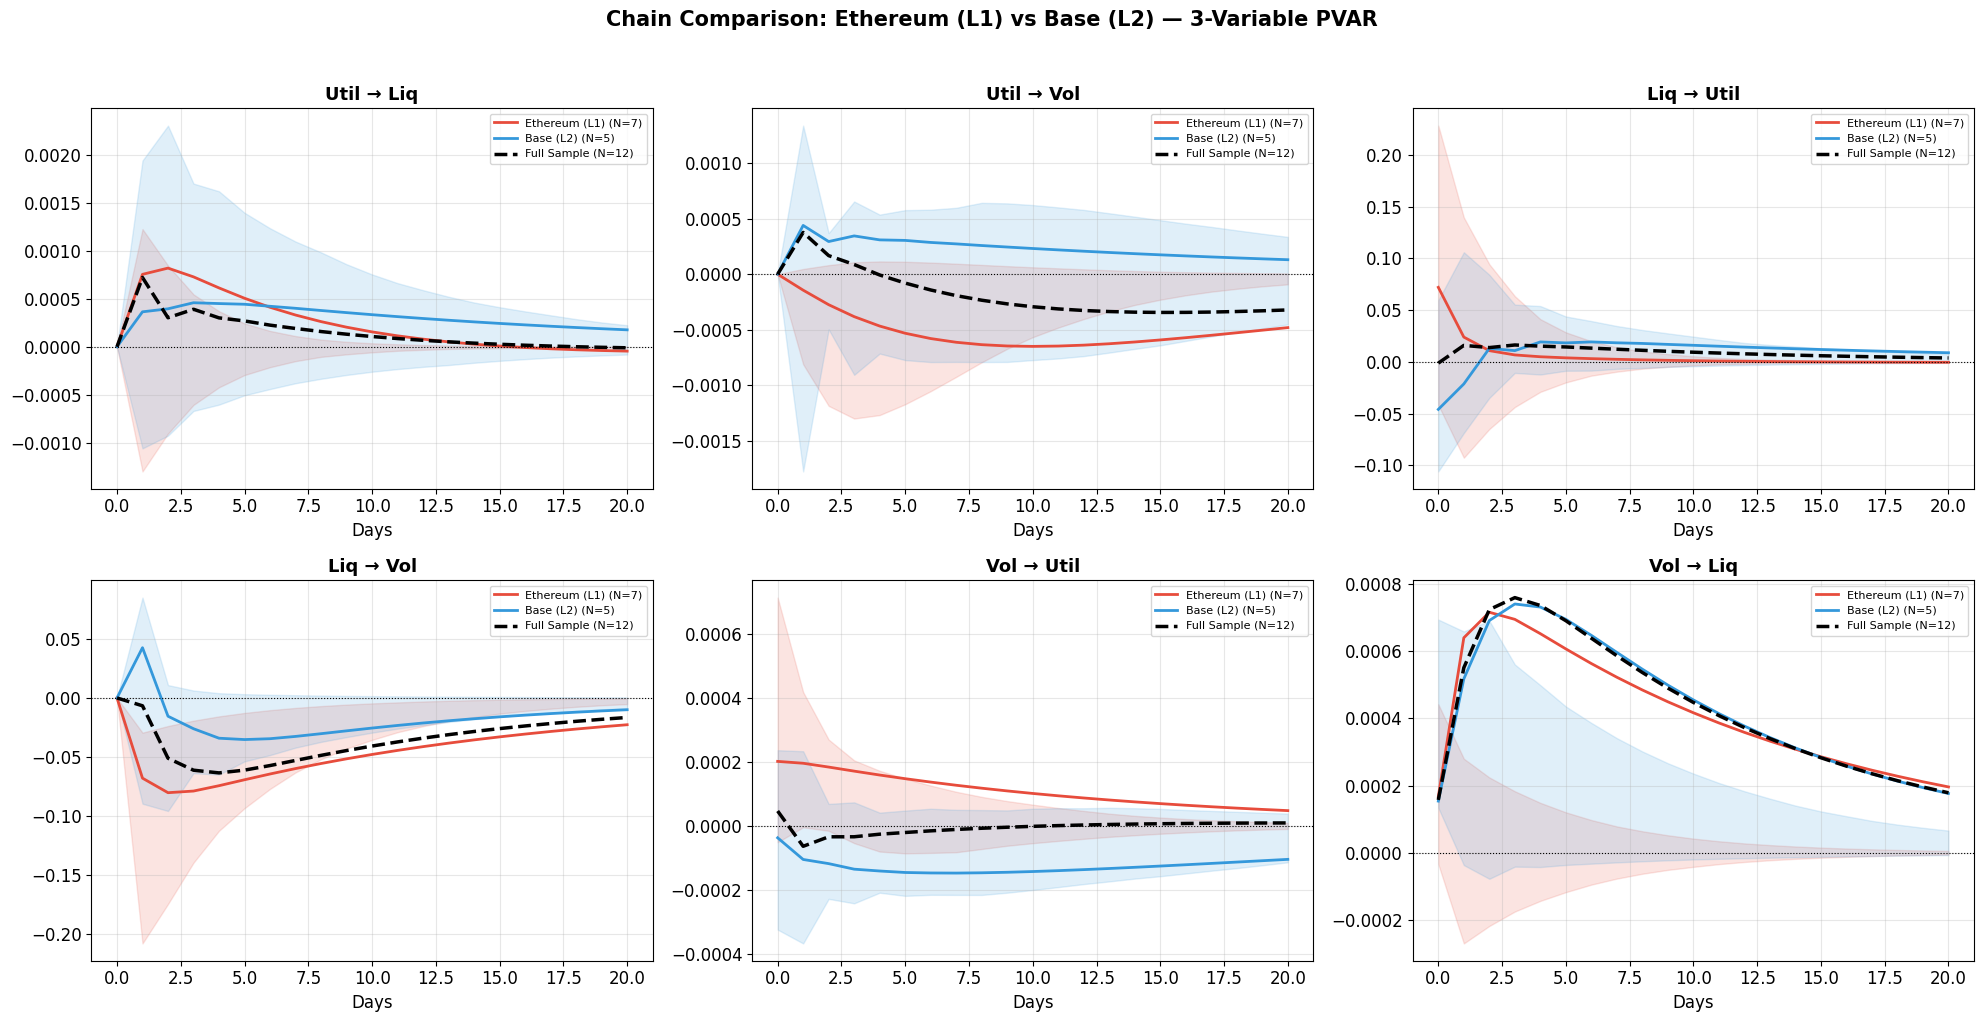

In [31]:
# Cross-variable IRFs under ordering [util=0, liq=1, vol=2]
chain_cross_irfs = [
    (0, 1, 'Util → Liq'),
    (0, 2, 'Util → Vol'),
    (1, 0, 'Liq → Util'),
    (1, 2, 'Liq → Vol'),
    (2, 0, 'Vol → Util'),
    (2, 1, 'Vol → Liq'),
]

chain_colors = {
    'Ethereum (L1)': '#e74c3c',
    'Base (L2)': '#3498db',
    'Full Sample': 'black',
}

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for ax, (imp, resp, title) in zip(axes.flat, chain_cross_irfs):
    for label, color in chain_colors.items():
        res = chain_results[label]
        vals = res['irf_orth'][:, imp, resp]
        periods = range(len(vals))
        lw = 2.5 if label == 'Full Sample' else 2.0
        ls = '-' if label != 'Full Sample' else '--'
        ax.plot(periods, vals, color=color, lw=lw, ls=ls,
                label=f'{label} (N={res["n_csus"]})')
        if res['ci_lo'] is not None and label != 'Full Sample':
            ax.fill_between(periods,
                            res['ci_lo'][:, imp, resp],
                            res['ci_hi'][:, imp, resp],
                            alpha=0.15, color=color)
    ax.axhline(0, color='black', ls=':', lw=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Days')
    ax.legend(fontsize=8)

fig.suptitle('Chain Comparison: Ethereum (L1) vs Base (L2) — 3-Variable PVAR',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/irf_3var_chain_comparison.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

### 20e. IRF Summary Table — Chain Comparison

In [32]:
chain_irf_rows = []
for label, res in chain_results.items():
    for imp, resp, name in chain_cross_irfs:
        vals = res['irf_orth'][:, imp, resp]
        peak_idx = int(np.argmax(np.abs(vals)))
        cumul = np.sum(vals)
        
        n_sig = 0
        if res['ci_lo'] is not None:
            for h in range(len(vals)):
                lo = res['ci_lo'][h, imp, resp]
                hi = res['ci_hi'][h, imp, resp]
                if lo > 0 or hi < 0:
                    n_sig += 1
        
        chain_irf_rows.append({
            'Chain': label,
            'IRF Path': name,
            'Impact (t=1)': f'{vals[1]:.5f}',
            'Peak': f'{vals[peak_idx]:.5f}',
            'Peak Period': f't+{peak_idx}',
            'Cumulative': f'{cumul:.5f}',
            'Sign': '+' if cumul > 0 else '−',
            'Sig Horizons': f'{n_sig}/21',
        })

chain_irf_df = pd.DataFrame(chain_irf_rows)
print("Table 11: IRF Summary — Chain Comparison")
print("=" * 110)
for label in chain_results:
    sub = chain_irf_df[chain_irf_df['Chain'] == label]
    print(f"\n--- {label} (N={chain_results[label]['n_csus']}, {chain_results[label]['n_obs']:,} obs, {chain_results[label]['lags']} lags) ---")
    print(sub.drop(columns='Chain').to_string(index=False))

Table 11: IRF Summary — Chain Comparison

--- Ethereum (L1) (N=7, 1,815 obs, 1 lags) ---
  IRF Path Impact (t=1)     Peak Peak Period Cumulative Sign Sig Horizons
Util → Liq      0.00076  0.00082         t+2    0.00493    +         0/21
Util → Vol     -0.00014 -0.00065        t+10   -0.01065    −         0/21
Liq → Util      0.02394  0.07200         t+0    0.13295    +         0/21
 Liq → Vol     -0.06786 -0.08016         t+2   -0.97353    −        20/21
Vol → Util      0.00020  0.00020         t+0    0.00234    +         0/21
 Vol → Liq      0.00064  0.00072         t+2    0.00872    +         0/21

--- Base (L2) (N=5, 1,459 obs, 2 lags) ---
  IRF Path Impact (t=1)     Peak Peak Period Cumulative Sign Sig Horizons
Util → Liq      0.00036  0.00046         t+3    0.00641    +         0/21
Util → Vol      0.00044  0.00044         t+1    0.00470    +         0/21
Liq → Util     -0.02132 -0.04591         t+0    0.20007    +         0/21
 Liq → Vol      0.04253  0.04253         t+1   -0.376

### 20f. Export Chain Comparison Results

In [33]:
# --- Table 9: Chain Summary Statistics ---
chain_stats_df.to_csv(f'{results_dir}/table9_chain_summary_stats.csv', index=False)

# --- Table 10: Chain Granger Causality ---
gc_chain_df.to_csv(f'{results_dir}/table10_chain_granger_causality.csv', index=False)

# --- Table 11: Chain IRF Summary ---
chain_irf_df.to_csv(f'{results_dir}/table11_chain_irf_summary.csv', index=False)

# --- Chain IRF point estimates ---
chain_irf_detail = []
for label, res in chain_results.items():
    for imp, resp, name in chain_cross_irfs:
        vals = res['irf_orth'][:, imp, resp]
        for h in range(len(vals)):
            row = {'Chain': label, 'IRF Path': name, 'Horizon': h, 'IRF': vals[h]}
            if res['ci_lo'] is not None:
                row['CI_lo'] = res['ci_lo'][h, imp, resp]
                row['CI_hi'] = res['ci_hi'][h, imp, resp]
                row['Significant'] = (row['CI_lo'] > 0) or (row['CI_hi'] < 0)
            chain_irf_detail.append(row)
pd.DataFrame(chain_irf_detail).to_csv(f'{results_dir}/chain_irf_point_estimates.csv', index=False)

# List all results files
all_files = sorted(os.listdir(results_dir))
print("All results files:")
print("-" * 60)
for f in all_files:
    size = os.path.getsize(f'{results_dir}/{f}')
    print(f"  {f} ({size:,} bytes)")
print(f"\nTotal: {len(all_files)} files")

All results files:
------------------------------------------------------------
  chain_irf_point_estimates.csv (37,361 bytes)
  figure_key_irf_comparison.png (369,800 bytes)
  irf_3var_base_vs_eth.png (366,712 bytes)
  irf_3var_chain_comparison.png (642,899 bytes)
  irf_3var_cross_comparison.png (676,149 bytes)
  irf_3var_full_grid.png (578,416 bytes)
  irf_3var_mechanism_comparison.png (672,597 bytes)
  irf_3var_ordering_robustness.png (583,895 bytes)
  irf_3var_pooled_vs_isolated.png (586,807 bytes)
  irf_grid_full_sample.png (208,438 bytes)
  irf_grid_isolated_only.png (207,110 bytes)
  irf_grid_pooled_only.png (215,628 bytes)
  irf_grid_stablecoin_markets.png (219,637 bytes)
  irf_grid_volatile_markets.png (209,880 bytes)
  irf_subsample_comparison.png (289,664 bytes)
  irf_util_vol_full_sample.png (111,816 bytes)
  irf_util_vol_isolated_only.png (106,582 bytes)
  irf_util_vol_pooled_only.png (115,601 bytes)
  irf_util_vol_stablecoin_markets.png (109,771 bytes)
  irf_util_vol_vola